---

# Data Science Competition JOINTS x INSPIRE UGM 2026 (v10)

*Memprediksi penjualan tiket harian D4 sampai D10 per pasangan film dan klaster bioskop dari tiga hari pertama, dengan model hurdle yang memisahkan keputusan bioskop mencopot film dari jumlah penonton, dikoreksi untuk kebijakan pencopotan periode uji yang terukur dari data berlabel periode uji.*

---

## [Nama Tim]

- [Nama Anggota 1] (Ketua)
- [Nama Anggota 2]
- [Nama Anggota 3]

---

## Table of Contents

1. [**Introduction**](#1)
2. [**Initialization**](#2)
3. [**Data Acquisition & Audit**](#3)
4. [**Exploratory Data Analysis**](#4)
5. [**Data Cleaning**](#5)
6. [**Preprocessing**](#6)
7. [**Feature Engineering**](#7)
8. [**Modeling**](#8)
9. [**Evaluation**](#9)
10. [**Inference & Submission**](#10)


---

# Introduction <a name="1"></a>

---

## Overview

*Operator bioskop harus menentukan alokasi layar ketika film baru hanya memiliki tiga hari riwayat penjualan. Data latih mencakup April sampai September 2025, sedangkan film uji dirilis Oktober 2025 sampai Maret 2026: musim sepi, libur Natal, Ramadan, dan Lebaran.*

*Versi sebelumnya memiliki MASE validasi yang dibobot ke komposisi uji (TW-MASE) 0,377 sampai 0,388 dengan peringkat yang sama seperti leaderboard, tetapi dengan offset tetap sekitar 0,07. Offset yang sama pada model yang berbeda menandakan kesalahan sistematis yang diwarisi dari data latih. v4 menemukan salah satu sumbernya (di periode uji bioskop jauh lebih jarang mencopot film pada tingkat penonton yang sama) dan turun ke 0,4481. v5 menambah dua hal: fitur kompetisi per klaster pada klasifier pencopotan, dan prediksi minggu Lebaran yang diturunkan dari total klaster Lebaran 2025 di data latih, dan turun ke 0,4087. Dengan itu, TW-MASE di dunia dengan separuh pergeseran pencopotan (v5: 0,4066) praktis sama dengan leaderboard, sehingga metrik ini menjadi metrik keputusan. v6 memakai TabPFN-3.5 dan mencapai 0,4012. v7 menguji TabPFN-3.5 yang di-fine-tune (loss CRPS): lebih buruk dari versi in-context (TW-MASE 0,3968 vs 0,3840), bobot blend nol, dan dihapus. v8 memperbaiki metrik validasi: pasangan yang baru mulai laku di D3 (pembukaan terlambat) 2,3 kali lebih banyak di bobot lama daripada di data uji, sehingga bobot uji kini mencocokkan komposisi **skala x hari penjualan pertama**. TabPFN-3.5 memakai 16 anggota ensemble (bagging 3 seed pada hurdle LightGBM diuji, tidak di atas noise) dan mencapai 0,39991. **v9 mematuhi batas bobot model 200 MB**: TabPFN-3.5 (876 MB) diganti dua tabular foundation model yang muat, TabPFN-2.6 (51,6 MB) dan EXAONE-Tabular dari LG AI Research (84,5 MB). Keduanya dinilai out-of-fold dan bobot blend dipilih otomatis; checkpoint yang dipakai disimpan bersama model LightGBM dalam satu berkas bobot di bawah 200 MB sehingga notebook dapat dijalankan ulang tanpa internet. **v10 memperbaiki alat ukur sebelum mencari skor**: statistik klaster dihitung fold-local (sebelumnya melihat transaksi film validasi), backtest temporal bulanan ditambahkan, dan kandidat perbaikan (perubahan jumlah show dan tiket per show dengan nested cross-fitting; metadata resmi) diuji satu per satu terhadap baseline bersih dengan aturan adopsi yang ditulis sebelum hasil. Kalender libur sekolah Jawa Barat (22% baris uji) dikoreksi dari sumber resmi Disdik Jabar.*

## Aim

*Memprediksi `total_ticket` D4 sampai D10 untuk 72.611 baris uji dengan MASE sekecil mungkin pada private leaderboard, memakai metrik validasi yang terbukti sejalan dengan leaderboard.*

## Metric

***Mean Absolute Scaled Error (MASE)** membagi galat absolut setiap baris dengan skala pasangan, yaitu rata-rata D1 sampai D3 yang dibatasi minimal 1. MASE setara MAE pada rasio $r = y / s_p$, sehingga prediksi optimal adalah median bersyarat. Karena MASE adalah rata-rata biasa per baris, komposisi baris uji (misalnya porsi pasangan kecil) langsung menentukan skor.*

$$s_p = \max\left(\frac{1}{3}\sum_{d=1}^{3} y_{p,d},\ 1\right) \qquad \text{MASE} = \frac{1}{N}\sum_{i=1}^{N}\frac{|y_i - \hat{y}_i|}{s_{p(i)}}$$

## Dataset

*Data bersumber dari Kaggle Competition Data Science JOINTS x INSPIRE UGM 2026.*

*`train.csv` berisi 138.959 transaksi harian (1 April sampai 30 September 2025). `test_history.csv` berisi 32.323 transaksi D1 sampai D3 dari 163 judul uji, dan `test.csv` berisi 72.611 baris target (10.373 pasangan x 7 hari). Hari tanpa transaksi tidak tercatat dan bernilai nol.*

*Data digunakan untuk merekonstruksi sampel latih dengan aturan panitia, lalu memprediksi D4 sampai D10.*

**Attributes**

1.  `date_show`       : Tanggal penayangan
2.  `cinema_ids`      : ID anonim klaster bioskop
3.  `city_name`       : Kota lokasi klaster
4.  `movie_title`     : Judul film, termasuk penanda format (3D, IMAX 2D, IMAX 3D)
5.  `occupation_rate` : Persentase kursi terisi (0 sampai 100)
6.  `total_show`      : Jumlah pertunjukan

**Target**
 `total_ticket`       : Jumlah tiket terjual per pasangan per tanggal (0 bila tidak ada transaksi)

## Approach: Hurdle + L1 dengan Koreksi Kebijakan Pencopotan

*Temuan utama v3: galat per ukuran pasangan stabil antara periode latih dan periode uji, tetapi data uji memuat empat kali lebih banyak pasangan kecil (skala di bawah 20) yang galatnya paling besar. MASE validasi biasa karena itu terlalu optimistis. Seluruh keputusan di notebook ini diambil dengan **TW-MASE**, yaitu galat out-of-fold yang dibobot ke komposisi data uji menurut bucket skala x hari penjualan pertama (D1, D2, atau D3).*

*Target $r = y / (s_p c_{mult})$ adalah campuran: nol bila bioskop mencopot film, positif bila tidak. Prediksi optimal MASE adalah median campuran: $0$ bila $p_0 \ge 0{,}5$, selain itu kuantil ke-$(0{,}5 - p_0)/(1 - p_0)$ dari bagian positif. Model hurdle LightGBM (klasifier $p_0$ dan 19 regresi kuantil) serta foundation model tabular (EXAONE-Tabular atau TabPFN v2, kuantil prediktif) memakai rumus ini. Di periode uji, $p_0$ digeser $\text{logit}\,p_0' = \text{logit}\,p_0 + \lambda a$, dengan $a$ diukur dari data berlabel periode uji dan $\lambda = 0{,}5$ dipilih dengan minimax regret dari tiga sumber bukti. Model L1 ikut di-blend sebagai lindung nilai karena lebih tahan pada pasangan yang ternyata dicopot.*

```
train.csv -> D1 rilis resmi (segmen kontinu) -> simulasi aturan panitia -> + film rilis terbatas (latih saja)
                                                   |
test_history.csv ---------------------------------+--> build fitur (pasangan, film, kalender, jadwal, klaster)
                                                   |
      LightGBM L1 + hurdle (p0 + kuantil)  +  foundation model per horizon (opsional, FM_MODE)
                                                   |  p0 digeser lambda x a (a dari proxy periode uji)
                  y_hat = r_hat x c_mult x s_p, bobot blend dipilih dengan TW-MASE -> submission.csv
```

*Validasi: 5 fold dikelompokkan per judul dasar film (versi 2D, 3D, IMAX satu film di fold yang sama).*

---

# Initialization <a name="2"></a>

---

## Environment Setup

Notebook dirancang untuk Kaggle GPU T4 x2 dengan internet aktif (unduh bobot TabPFN dari Hugging Face). TabPFN memakai GPU pertama; LightGBM (L1, klasifier, dan 19 regresi kuantil) berjalan di CPU dengan `deterministic=True`. Recorded runtime v3 di T4: TabPFN OOF 18 menit dan fit akhir 21 menit; v4 menambah sekitar 15 sampai 25 menit untuk hurdle LightGBM.

In [1]:
!nvidia-smi

Mon Oct  5 04:07:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

The following cell installs all libraries used in this notebook.

In [2]:
%pip install -q lightgbm==4.6.0 tabpfn==9.0.0 huggingface_hub==0.34.4 scikit-learn==1.6.1 pandas==2.2.3 scipy==1.15.2 matplotlib==3.10.0 seaborn==0.13.2
%pip install -q --no-deps "exaonetabular @ git+https://github.com/LGAI-Research/EXAONE-Tabular.git@8638e07d09fad154249bd75ba4786181491f7025"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.5/827.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 27.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pa

## Import Libraries

In [3]:
import os
import random
import time
import pickle
import zlib
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import torch
from IPython.display import display
from huggingface_hub import hf_hub_download
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion
try:  # EXAONE-Tabular is optional: if it cannot be imported, the notebook runs without it
    import exaonetabular.model.attention as _xa
    from exaonetabular import EXAONETabularRegressor
    from torch.nn.attention import SDPBackend
    if torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] < 8:
        # T4 (sm75) has no FlashAttention kernel, which EXAONE picks by default -> memory-efficient / math kernels
        _xa._select_sdpa_backend = lambda q, c, hw, *, on_cuda, policy: (
            SDPBackend.EFFICIENT_ATTENTION if on_cuda and hw % 8 == 0 else SDPBackend.MATH)
except Exception as e:
    print('EXAONE-Tabular unavailable:', repr(e)[:200])
    EXAONETabularRegressor = None
try:
    from kaggle_secrets import UserSecretsClient
except ImportError:
    UserSecretsClient = None

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
PAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
sns.set_theme(style='whitegrid', palette=PAL, rc={'axes.spines.top': False, 'axes.spines.right': False})

## Seed Everything

In [4]:
def seed_everything(seed: int = 2026):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(2026)

## Settings

Seluruh path, konstanta hasil EDA, hyperparameter, dan flag dipusatkan di sini. `HURDLE_W` adalah bobot hurdle dalam komponen LightGBM dan `LAMBDA` porsi pergeseran kebijakan pencopotan yang diterapkan; keduanya dipilih dengan analisis keputusan di Bagian 8. `LEB_RHO` adalah porsi total pasar minggu Lebaran 2025 yang diasumsikan dicapai film Lebaran 2026 (Bagian 10). Tidak ada nilai yang disetel pada leaderboard.

In [5]:
class Settings:
    SEED       = 2026
    _ON_KAGGLE = Path('/kaggle/input').exists()

    DATA_DIR   = (
        next(Path('/kaggle/input').rglob('train.csv')).parent
        if _ON_KAGGLE else Path('../data')
    )
    OUTPUT_DIR = Path('/kaggle/working') if _ON_KAGGLE else Path('../outputs/v10')
    FIG_DIR    = OUTPUT_DIR / 'figures'

    TRAIN_END  = pd.Timestamp('2025-09-30')
    OUTAGE     = pd.to_datetime(['2025-06-07', '2025-06-09', '2025-06-10', '2025-06-13', '2025-06-16'])
    D1_FRAC    = 0.5
    MIN_NC     = 25
    USE_LIMITED = True

    DOW_PROF   = np.array([0.811, 0.789, 0.811, 0.783, 0.848, 1.290, 1.282])
    HOL_LEVEL  = 1.29
    SCHOOL_WD  = 1.15
    QS         = np.round(np.arange(0.05, 1.0, 0.05), 2)
    TAB_QS     = np.round(np.arange(0.02, 1.0, 0.02), 2)
    ZERO_EPS   = 0.02
    HURDLE_W   = 0.75
    LAMBDA     = 0.5
    LEB_RHO    = 0.5
    LEB_DAY1   = 0.75
    TW_BINS    = [0, 5, 20, 50, 100, 200, 500, 1e9]

    N_FOLDS    = 5
    SEEDS      = [2026, 2027, 2028, 2029, 2030]
    LGB_PARAMS = dict(objective='l1', learning_rate=0.03, num_leaves=63, min_child_samples=100,
                      feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
                      n_estimators=800, deterministic=True, force_row_wise=True, n_jobs=4, verbose=-1)

    FM_MODE      = 'exaone'   # 'exaone' | 'tabpfn_v2' (revision 11 Jun 2025, before the cutoff) | 'none'
    FM_EST       = 8
    EXAONE_REPO  = 'LG-AI-Research/EXAONE-Tabular'              # 84.5 MB
    EXAONE_FILE  = 'exaone-tabular-regressor-v1_default.safetensors'
    EXAONE_REV   = '093ad1c2613e1e95d26df8610451d2e02ed53cbe'
    EXAONE_SHA256 = '24891e14e649c6509f07ee62b5583e06544b68eaf9a9195ee58777eb9cf6fa0d'
    TABPFN_REPO  = 'Prior-Labs/TabPFN-v2-reg'                   # 44.4 MB
    TABPFN_FILE  = 'tabpfn-v2-regressor.ckpt'
    TABPFN_REV   = '213f8e38ec399a2a385fa46cab6f22b95cd90de8'
    TABPFN_SHA256 = '2ab5a07d5c41dfe6db9aa7ae106fc6de898326c2765be66505a07e2868c10736'
    STRICT       = True
    MAX_WEIGHTS_MB = 200
    KAPPA        = 0.5
    KAPPA_SEEDS  = 3
    ABL_MIN_GAIN  = 0.0015
    ABL_MONTH_TOL = 0.003
    ABL_MIN_FOLDS = 3
    ABL_KAPPA_TOL = 0.002
    FM_MIN_GAIN   = 0.001
    REGIONAL_CAL  = True
    DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

CFG = Settings()
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CFG.FIG_DIR.mkdir(parents=True, exist_ok=True)
print(CFG.DATA_DIR, CFG.DEVICE)

/kaggle/input/competitions/datajointsxinspire cuda


## Load Dataset

Semua berkas resmi dibaca dengan kolom tanggal langsung di-parse. Tidak ada visualisasi di sini.

In [6]:
read = lambda f, **k: pd.read_csv(CFG.DATA_DIR / f, **k)
train   = read('train.csv', parse_dates=['date_show'])
hist    = read('test_history.csv', parse_dates=['date_show'])
test    = read('test.csv', parse_dates=['date_show'])
sub     = read('sample_submission.csv')
movies  = read('movies.csv')
hol     = read('holidays.csv', parse_dates=['date'])
price   = read('ticket_prices.csv')
KEY     = ['movie_title', 'cinema_ids']

for n, x in [('train', train), ('test_history', hist), ('test', test), ('movies', movies),
             ('holidays', hol), ('ticket_prices', price)]:
    print(f'{n:14s} {x.shape}')

train          (138959, 7)
test_history   (32323, 7)
test           (72611, 5)
movies         (397, 7)
holidays       (366, 4)
ticket_prices  (207, 3)


---

# Data Acquisition & Audit <a name="3"></a>

---

Integritas data diperiksa sebelum analisis: rentang tanggal, nilai hilang, duplikat kunci, konsistensi klaster ke kota, dan irisan film serta klaster antara data latih dan data uji.

In [7]:
rows = []
for n, x in [('train', train), ('test_history', hist), ('test', test)]:
    rows.append(dict(file=n, rows=len(x), start=x.date_show.min().date(), end=x.date_show.max().date(),
                     films=x.movie_title.nunique(), cinemas=x.cinema_ids.nunique(), n_missing=int(x.isna().sum().sum())))
display(pd.DataFrame(rows))
for n, x in [('train', train), ('test_history', hist)]:
    print(f"{n}: duplicate (date, cinema, film) = {x.duplicated(['date_show'] + KEY).sum()}, zero-ticket rows = {(x.total_ticket == 0).sum()}")
print('clusters mapped to >1 city:', (pd.concat([train, hist]).groupby('cinema_ids').city_name.nunique() > 1).sum())
print('test ids aligned with sample_submission:', (sub.id.values == test.id.values).all())
print('test films also in train (previews):', len(set(test.movie_title) & set(train.movie_title)))
print('test clusters unseen in train:', len(set(test.cinema_ids) - set(train.cinema_ids)))

,file,rows,start,end,films,cinemas,n_missing
0,train,138959,2025-04-01,2025-09-30,237,117,0
1,test_history,32323,2025-10-01,2026-03-20,163,121,0
2,test,72611,2025-10-04,2026-03-27,160,121,0


train: duplicate (date, cinema, film) = 0, zero-ticket rows = 0
test_history: duplicate (date, cinema, film) = 0, zero-ticket rows = 0
clusters mapped to >1 city: 0
test ids aligned with sample_submission: True
test films also in train (previews): 10
test clusters unseen in train: 4


#### Insights

> Tidak ada nilai hilang, duplikat kunci, maupun baris bertiket nol: hari tanpa transaksi memang tidak tercatat, sehingga target harus diisi nol secara eksplisit. Sepuluh film uji muncul di train hanya sebagai pratinjau di beberapa klaster, dan empat klaster uji tidak pernah muncul di train.

---

# Exploratory Data Analysis <a name="4"></a>

---

EDA menjawab tiga pertanyaan yang langsung mengubah pipeline: bagaimana panitia membentuk data uji, periode kalender apa yang tidak pernah dilihat data latih, dan apakah level pasar periode uji berbeda.

## Aturan Seleksi Pasangan dan Filter Rilis Luas

`test_history.csv` memuat 11.823 pasangan, tetapi `test.csv` hanya 10.373. Pasangan dikelompokkan menurut hari terakhir yang masih bertransaksi, lalu cakupan klaster D1 film uji dibandingkan dengan judul di `movies.csv` yang tidak dipakai.

In [8]:
base_title = lambda t: t.str.replace(r'\s*\((IMAX 2D|IMAX 3D|3D)\)\s*$', '', regex=True).str.strip()
fmt = lambda t: t.str.extract(r'\((IMAX 2D|IMAX 3D|3D)\)\s*$')[0].fillna('2D')

d1_test = hist.groupby('movie_title').date_show.min()
h = hist.join(d1_test.rename('d1'), on='movie_title')
h['d'] = (h.date_show - h.d1).dt.days + 1
ph = h.groupby(KEY).d.max().rename('last_day').reset_index()
ph = ph.merge(test[KEY].drop_duplicates().assign(in_test=1), how='left').fillna({'in_test': 0})
display(pd.crosstab(ph.last_day, ph.in_test, margins=True))
nc1 = h[h.d == 1].groupby('movie_title').cinema_ids.nunique()
print('smallest D1 coverage of 2D test films:', nc1[fmt(pd.Series(nc1.index, index=nc1.index)) == '2D'].nsmallest(4).to_dict())
known = set(base_title(pd.Series(train.movie_title.unique()))) | set(base_title(pd.Series(hist.movie_title.unique())))
print('titles in movies.csv used nowhere:', len(set(movies.original_title) - known))
print('D1 weekday of test films:', d1_test.dt.day_name().value_counts().to_dict())

in_test,0.0,1.0,All
last_day,,,
1,514,0,514
2,936,0,936
3,0,10373,10373
All,1450,10373,11823


smallest D1 coverage of 2D test films: {'EPIC: ELVIS PRESLEY IN CONCERT': 28, '5 CENTIMETERS PER SECOND (ANIMATION)': 30, 'ONCE WE WERE US': 30, 'SETANNYA CUAN': 33}
titles in movies.csv used nowhere: 56
D1 weekday of test films: {'Wednesday': 67, 'Thursday': 65, 'Friday': 24, 'Saturday': 5, 'Tuesday': 2}


#### Insights

> Pasangan masuk data uji **jika dan hanya jika** bertransaksi pada D3. Film 2D terkecil di data uji dibuka di 28 klaster, sedangkan 56 judul lain (Bollywood rilis terbatas, konser, nobar) tidak dipakai: data uji hanya berisi rilis luas. D1 hampir selalu Rabu atau Kamis, yaitu tanggal rilis resmi.

## Efek Kalender dan Periode yang Tidak Ada di Data Latih

Efek kalender diisolasi dengan membagi penjualan setiap pasangan-hari dengan rata-rata bergerak 7 hari terpusat milik pasangan itu sendiri, sehingga umur film dan ukuran klaster terhapus.

weekday multiplier: {'Mon': 0.814, 'Tue': 0.794, 'Wed': 0.811, 'Thu': 0.783, 'Fri': 0.853, 'Sat': 1.32, 'Sun': 1.282}


,name,dow,excess
date_show,,,
2025-04-18,Wafat Yesus Kristus,4,1.54
2025-04-20,Kebangkitan Yesus Kristus (Paskah),6,0.88
2025-05-01,Hari Buruh Internasional,3,1.85
2025-05-12,Hari Raya Waisak 2569 BE,0,1.88
2025-05-29,Kenaikan Yesus Kristus,3,1.98
2025-06-01,Hari Lahir Pancasila,6,0.35
2025-06-06,Idul Adha 1446 H,4,3.08
2025-06-27,1 Muharam Tahun Baru Islam 1447 H,4,1.48
2025-08-17,Proklamasi Kemerdekaan Republik Indonesia,6,1.11


xmas     test rows   5235 (7.2%), films 15
ramadan  test rows  12408 (17.1%), films 37
lebaran  test rows   4417 (6.1%), films 7


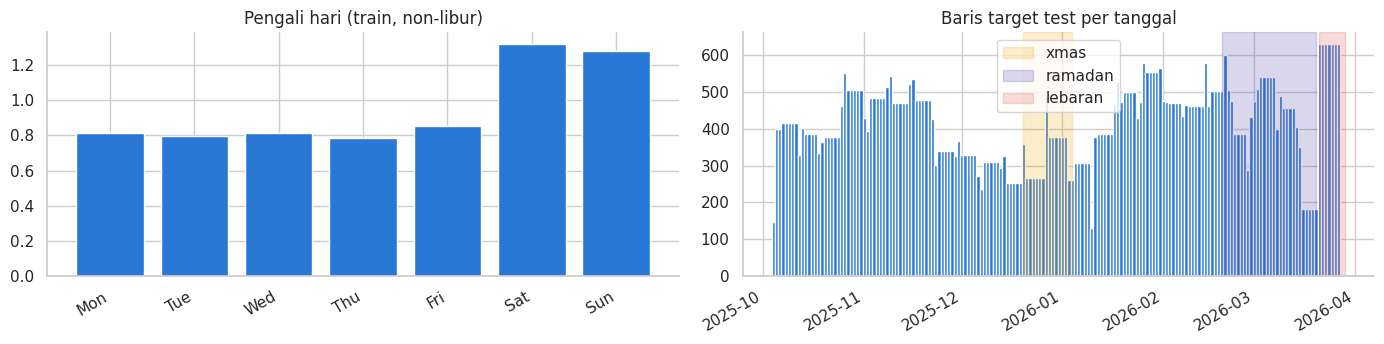

In [9]:
DOW = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
x = train.set_index('date_show').groupby(KEY).total_ticket.apply(lambda s: s.asfreq('D', fill_value=0)).reset_index()
x['m7'] = x.groupby(KEY).total_ticket.transform(lambda s: s.rolling(7, center=True).mean())
x = x[(x.m7 >= 20) & ~x.date_show.isin(CFG.OUTAGE)].merge(hol, left_on='date_show', right_on='date', how='left')
x['mult'] = x.total_ticket / x.m7
day = x.groupby('date_show').agg(mult=('mult', 'median'), hol=('holiday_tipe', 'first'), name=('holiday_name', 'first'))
day['dow'] = day.index.dayofweek
prof = day[day.hol == 'normal'].groupby('dow').mult.median()
day['excess'] = day.mult / day.dow.map(prof)
print('weekday multiplier:', dict(zip(DOW, prof.round(3))))
display(day[day.hol == 'holiday'][['name', 'dow', 'excess']].round(2))

SEGMENTS = {'xmas': ('2025-12-20', '2026-01-04'), 'ramadan': ('2026-02-19', '2026-03-20'), 'lebaran': ('2026-03-21', '2026-03-29')}
for n, (a, b) in SEGMENTS.items():
    m = test.date_show.between(a, b)
    print(f'{n:8s} test rows {m.sum():6d} ({m.mean():.1%}), films {test[m].movie_title.nunique()}')

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
ax[0].bar(DOW, prof.values, color=PAL[0]); ax[0].set(title='Pengali hari (train, non-libur)')
cnt = test.groupby('date_show').size()
ax[1].bar(cnt.index, cnt.values, width=1, color=PAL[0])
for (n, (a, b)), c in zip(SEGMENTS.items(), [PAL[3], PAL[6], PAL[7]]):
    ax[1].axvspan(pd.Timestamp(a), pd.Timestamp(b), color=c, alpha=.2, label=n)
ax[1].set(title='Baris target test per tanggal'); ax[1].legend()
fig.autofmt_xdate(); plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'calendar.png'); plt.show()

#### Insights

> Sabtu dan Minggu sekitar 1,6 kali hari kerja, libur di hari kerja setara akhir pekan, libur di akhir pekan hampir tidak menambah. Sekitar 30% baris uji berada di periode yang tidak pernah ada di train: Ramadan (17,1%), libur Natal dan Tahun Baru (7,2%), dan Lebaran (6,1%). Efek kalender karena itu dimasukkan secara struktural sebagai pengali target, bukan dipelajari pohon keputusan yang tidak bisa ekstrapolasi.

## Level Pasar dan Ukuran Pasangan

Okupansi median per bulan dan distribusi skala pasangan D1 sampai D3 dibandingkan antara train dan data uji. Skala dihitung dengan rumus resmi pada seluruh pasangan yang laku di D3.

test pairs by scale bucket: {Interval(0.0, 5.0, closed='right'): 0.015, Interval(5.0, 20.0, closed='right'): 0.114, Interval(20.0, 50.0, closed='right'): 0.198, Interval(50.0, 100.0, closed='right'): 0.2, Interval(100.0, 200.0, closed='right'): 0.195, Interval(200.0, 500.0, closed='right'): 0.178, Interval(500.0, 1000000000.0, closed='right'): 0.1}


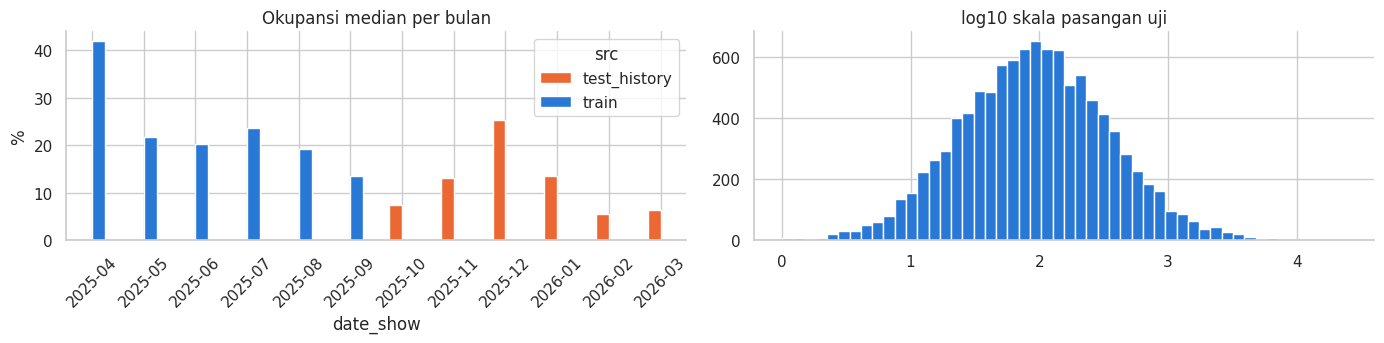

In [10]:
occ = pd.concat([train.assign(src='train'), hist.assign(src='test_history')])
occ_m = occ.groupby([occ.date_show.dt.to_period('M'), 'src']).occupation_rate.median().unstack()
s_te = (hist.groupby(KEY).total_ticket.sum() / 3).clip(lower=1).reindex(pd.MultiIndex.from_frame(test[KEY].drop_duplicates()))
bins = CFG.TW_BINS
print('test pairs by scale bucket:', pd.cut(s_te, bins).value_counts(normalize=True).sort_index().round(3).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
occ_m.plot.bar(ax=ax[0], rot=45, color=[PAL[1], PAL[0]]); ax[0].set(title='Okupansi median per bulan', ylabel='%')
ax[1].hist(np.log10(s_te), bins=50, color=PAL[0]); ax[1].set(title='log10 skala pasangan uji')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'market.png'); plt.show()

#### Insights

> Okupansi median Oktober 2025 (7,6%), Februari (5,5%), dan Maret 2026 (6,4%) berada di bawah semua bulan train (13,6% sampai 41,8%). Pasar periode uji jauh lebih sepi, sehingga pasangan uji jauh lebih kecil: 13% baris uji memiliki skala di bawah 20. Konsekuensinya diukur di Bagian 6 dan Bagian 8.

---

# Data Cleaning <a name="5"></a>

---

Target dibentuk dengan zero-fill, sehingga hari ketika sistem pelaporan mati akan menjadi nol palsu. Selain itu, akhir pekan pratinjau berbayar sebelum rilis resmi dapat terbaca sebagai D1.

dates with no data: [datetime.date(2025, 6, 13)]
dates with < 70% of clusters reporting: {Timestamp('2025-06-07 00:00:00'): 10.0, Timestamp('2025-06-09 00:00:00'): 1.0, Timestamp('2025-06-10 00:00:00'): 67.0, Timestamp('2025-06-11 00:00:00'): 76.0, Timestamp('2025-06-16 00:00:00'): 62.0}
A MINECRAFT MOVIE coverage 1-10 Apr: {Timestamp('2025-04-04 00:00:00'): 55, Timestamp('2025-04-05 00:00:00'): 68, Timestamp('2025-04-06 00:00:00'): 67, Timestamp('2025-04-09 00:00:00'): 93, Timestamp('2025-04-10 00:00:00'): 91}


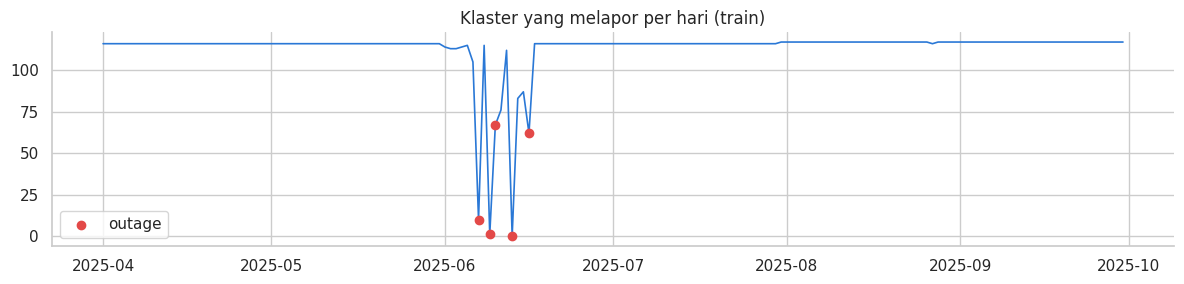

In [11]:
rep = train.groupby('date_show').cinema_ids.nunique().reindex(pd.date_range('2025-04-01', CFG.TRAIN_END))
print('dates with no data:', rep[rep.isna()].index.date.tolist())
print('dates with < 70% of clusters reporting:', rep[rep < 0.7 * rep.median()].to_dict())
mc = train[train.movie_title == 'A MINECRAFT MOVIE'].groupby('date_show').cinema_ids.nunique()
print('A MINECRAFT MOVIE coverage 1-10 Apr:', mc.loc[:'2025-04-10'].to_dict())
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(rep.index, rep.fillna(0), lw=1.2)
ax.scatter(CFG.OUTAGE, rep.reindex(CFG.OUTAGE).fillna(0), color=PAL[7], zorder=3, label='outage')
ax.set(title='Klaster yang melapor per hari (train)'); ax.legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'outage.png'); plt.show()

#### Insights

> Lima tanggal Juni 2025 adalah outage pelaporan (13 Juni kosong, 9 Juni hanya 1 klaster). Baris target pada tanggal tersebut dibuang dan film yang D1 sampai D3-nya menyentuh outage tidak dijadikan sampel. A MINECRAFT MOVIE memiliki pratinjau 4 sampai 6 April lalu jeda sebelum rilis resmi 9 April: D1 dicari hanya di dalam segmen tayang kontinu yang memuat puncak cakupan.

---

# Preprocessing <a name="6"></a>

---

`train.csv` tidak memiliki penanda D1 sampai D10. Aturan panitia direplikasi: D1 rilis resmi, rilis luas, pasangan laku di D3, target nol diisi eksplisit. Hasilnya diverifikasi terhadap data uji, termasuk dengan tugas proxy yang memiliki label di dalam periode uji.

## Rekonstruksi D1 dan Simulasi Sampel

D1 adalah hari pertama cakupan klaster judul dasar mencapai 50% puncak, dicari di dalam segmen tayang kontinu yang memuat puncak. Judul dengan cakupan D1 di bawah 25 klaster dipisahkan sebagai film rilis terbatas: tidak pernah dievaluasi, tetapi dipakai sebagai data latih tambahan untuk pasangan kecil.

In [12]:
def release_dates(tx, frac=CFG.D1_FRAC, min_nc=CFG.MIN_NC):
    x = tx.assign(base=base_title(tx.movie_title))
    nc = x.groupby(['base', 'date_show']).cinema_ids.nunique()
    out = {}
    for b, s in nc.groupby(level=0):
        s = s.droplevel(0)
        s = s.reindex(pd.date_range(s.index.min(), s.index.max()), fill_value=0)
        pk = s.idxmax()
        z = s[:pk][s[:pk] == 0]
        seg = s[z.index.max() + pd.Timedelta(days=1):] if len(z) else s
        c = seg[seg >= frac * s.max()]
        if len(c) and c.iloc[0] >= min_nc:
            out[b] = c.index[0]
    t = x.drop_duplicates('movie_title').set_index('movie_title').base
    return t.map(pd.Series(out, dtype='datetime64[ns]')).dropna().rename('d1')


def simulate(tx, d1, last_date=CFG.TRAIN_END, bad=CFG.OUTAGE):
    d1 = d1[d1 + pd.Timedelta(days=9) <= last_date]
    if len(bad):
        d1 = d1[~np.any([(d1 <= b) & (d1 + pd.Timedelta(days=2) >= b) for b in bad], axis=0)]
    x = tx.merge(d1, left_on='movie_title', right_index=True)
    x['d'] = (x.date_show - x.d1).dt.days + 1
    hs = x[x.d.between(1, 3)].drop(columns=['d1', 'd']).reset_index(drop=True)
    pairs = x.loc[x.d == 3, KEY].drop_duplicates().merge(d1, left_on='movie_title', right_index=True)
    tg = pairs.loc[pairs.index.repeat(7)].copy()
    tg['date_show'] = tg.d1 + pd.to_timedelta(np.tile(np.arange(3, 10), len(pairs)), unit='D')
    y = x[x.d.between(4, 10)][KEY + ['date_show', 'total_ticket']]
    tg = tg.merge(y, on=KEY + ['date_show'], how='left').fillna({'total_ticket': 0})
    tg = tg[~tg.date_show.isin(bad)]
    tg['city_name'] = tg.cinema_ids.map(tx.drop_duplicates('cinema_ids').set_index('cinema_ids').city_name)
    return hs, tg.drop(columns='d1').reset_index(drop=True)


def pair_scale(h):
    return (h.groupby(KEY).total_ticket.sum() / 3).clip(lower=1).rename('scale')


def mase(y, p, s):
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(p)) / np.asarray(s)))


first = train.groupby('movie_title').date_show.min()
running = first[first == first.min()].index
D_wide = release_dates(train)
D_lim = release_dates(train, CFG.D1_FRAC, 0).drop(D_wide.index, errors='ignore').drop(running, errors='ignore')
hs, ts = simulate(train, D_wide.drop(running, errors='ignore'))
hl, tl = simulate(train, D_lim)
print(f'wide releases: {ts.movie_title.nunique()} films, {len(ts)} target rows | limited (train only): {tl.movie_title.nunique()} films, {len(tl)} rows')
print('A MINECRAFT MOVIE D1:', D_wide['A MINECRAFT MOVIE'].date())

wide releases: 143 films, 56372 target rows | limited (train only): 36 films, 1435 rows
A MINECRAFT MOVIE D1: 2025-04-09


Fungsi `simulate` diuji pada film sintetis: klaster B tidak laku di D3 sehingga harus dibuang, dan hari tanpa transaksi harus menjadi nol.

In [13]:
dd = pd.date_range('2025-05-01', periods=12)
toy = pd.DataFrame({'date_show': list(dd) + [dd[0], dd[1]], 'cinema_ids': ['A'] * 12 + ['B', 'B'], 'city_name': 'X',
                    'movie_title': 'M', 'total_ticket': list(range(1, 13)) + [5, 5], 'occupation_rate': 1.0,
                    'total_show': 1}).drop(index=5)
th_, tg_ = simulate(toy, pd.Series({'M': dd[0]}, name='d1'), bad=pd.DatetimeIndex([]))
assert set(tg_.cinema_ids) == {'A'} and tg_.total_ticket.tolist() == [4, 5, 0, 7, 8, 9, 10]
assert np.isclose(pair_scale(th_)[('M', 'B')], 10 / 3)
print('simulate() self-check passed')

simulate() self-check passed


#### Insights

> Aturan D1 memakai puncak cakupan sepanjang riwayat film, yaitu informasi masa depan. Audit lokal (`eda/53`) membandingkannya dengan aturan yang benar-benar kausal: D1 = hari pertama yang jendela D1 sampai D3-nya sendiri memiliki minimal 25 klaster setiap hari, tanpa melihat puncak. Aturan itu memindahkan 6 film (A MINECRAFT MOVIE ke pratayang berbayar 4 April, BELIEVE 20 hari lebih awal), mengubah skala 191 pasangan bersama (varian yang masih memakai segmen puncak: 125), dan membuang 15 film yang dibuka di minimal 25 klaster lalu runtuh di D2 sampai D3 (rasio cakupan D3/D1 median 0,34, misalnya ARTI CINTA 52 menjadi 2 klaster). Jarak KS rasio cakupan ke data uji memang turun (0,196 menjadi 0,106), tetapi hanya karena ekor bawah itu dibuang.

> Data uji justru memuat pembukaan yang runtuh seperti itu: 8 film uji punya hari dengan kurang dari 25 klaster (SEND HELP 52, 49, lalu 1 klaster; G-DRAGON IN CINEMA 55, 30, 3) dan 30 film uji memiliki rasio cakupan D3/D1 di bawah 0,8. Seleksi panitia karena itu konsisten dengan aturan cakupan D1 (aturan sekarang), bukan dengan syarat jendela lebar tiga hari. Aturan D1 dipertahankan dengan dasar ini, bukan karena perubahannya kecil.

## Verifikasi: Komposisi dan Periode Uji

Sampel simulasi dibandingkan dengan data uji. Karena target uji tidak tersedia, dibuat tugas proxy yang memiliki label di **dalam periode uji**: memprediksi D3 dari D1 dan D2. Model proxy dilatih pada train, lalu galatnya per bucket skala dibandingkan antara validasi silang train dan periode uji.

,train_share,test_share,train_cv_mase,test_period_mase,train_zero_D3,test_zero_D3
s,,,,,,
"(0.0, 5.0]",0.004,0.024,1.062,1.171,0.771,0.544
"(5.0, 20.0]",0.053,0.134,0.750,0.693,0.568,0.308
"(20.0, 50.0]",0.134,0.208,0.612,0.587,0.392,0.107
"(50.0, 100.0]",0.173,0.195,0.533,0.481,0.129,0.028
"(100.0, 200.0]",0.217,0.185,0.418,0.410,0.031,0.011
"(200.0, 500.0]",0.249,0.160,0.342,0.344,0.004,0.002
"(500.0, 1000000000.0]",0.170,0.093,0.355,0.285,0.002,0.000


proxy MASE: train CV 0.4544 | re-weighted to test scale mix 0.5232 | real test period 0.4950


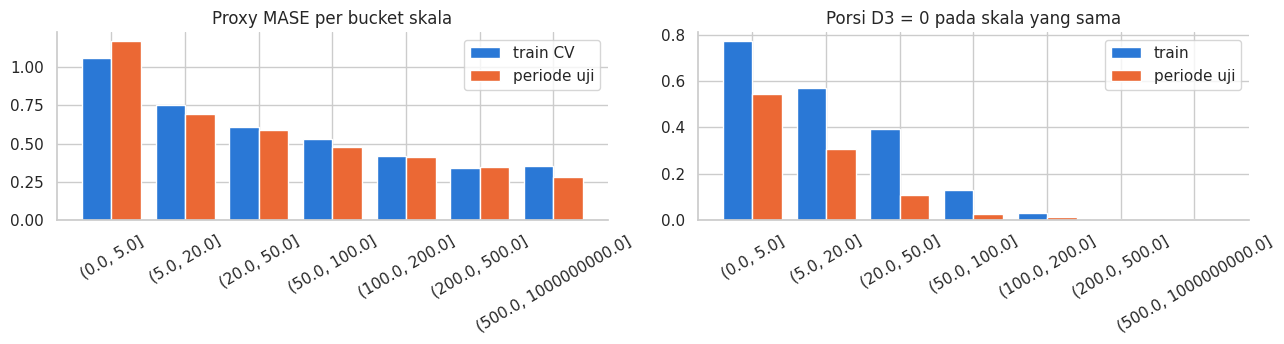

In [14]:
def proxy(hh):
    d1 = hh.groupby('movie_title').date_show.min().rename('d1')
    x = hh.join(d1, on='movie_title')
    x['d'] = (x.date_show - x.d1).dt.days + 1
    P = x.pivot_table(index=KEY, columns='d', values='total_ticket', fill_value=0).reindex(columns=[1, 2, 3], fill_value=0)
    S = x.pivot_table(index=KEY, columns='d', values='total_show', fill_value=0).reindex(columns=[1, 2], fill_value=0)
    O = x.pivot_table(index=KEY, columns='d', values='occupation_rate', fill_value=0).reindex(columns=[1, 2], fill_value=0)
    P = P[P[2] > 0]
    f = pd.DataFrame({'s': ((P[1] + P[2]) / 2).clip(lower=1), 'y': P[3]}, index=P.index)
    f['q1'], f['q2'], f['log_s'] = P[1] / f.s, P[2] / f.s, np.log1p(f.s)
    f['sh1'], f['sh2'] = S.reindex(P.index)[1], S.reindex(P.index)[2]
    f['sh_tr'] = (f.sh2 + 1) / (f.sh1 + 1)
    f['occ2'] = O.reindex(P.index)[2]
    f = f.reset_index().join(d1, on='movie_title')
    g = x[x.d <= 2].groupby(['movie_title', 'd']).total_ticket.sum().unstack().reindex(columns=[1, 2], fill_value=0)
    f['f_tr'] = f.movie_title.map((g[2] + 1) / (g[1] + 1))
    f['f_log'] = f.movie_title.map(np.log1p(g.mean(axis=1)))
    f['f_nc'] = f.movie_title.map(x[x.d == 2].groupby('movie_title').cinema_ids.nunique())
    f['d1_dow'] = f.d1.dt.dayofweek
    return f


PA, PB = proxy(hs), proxy(hist)
pc = ['q1', 'q2', 'log_s', 'sh_tr', 'f_tr', 'f_log', 'd1_dow']
pm = dict(objective='l1', n_estimators=400, learning_rate=0.03, num_leaves=31, min_child_samples=100, verbose=-1, deterministic=True, force_row_wise=True)
oofA = np.zeros(len(PA))
for a, b in GroupKFold(5).split(PA, groups=base_title(PA.movie_title)):
    m = lgb.LGBMRegressor(**pm, random_state=CFG.SEED).fit(PA.iloc[a][pc], PA.y.iloc[a] / PA.s.iloc[a])
    oofA[b] = np.clip(m.predict(PA.iloc[b][pc]), 0, None) * PA.s.values[b]
m = lgb.LGBMRegressor(**pm, random_state=CFG.SEED).fit(PA[pc], PA.y / PA.s)
pB = np.clip(m.predict(PB[pc]), 0, None) * PB.s.values
eA, eB = np.abs(PA.y - oofA) / PA.s, np.abs(PB.y - pB) / PB.s
cutA, cutB = pd.cut(PA.s, bins), pd.cut(PB.s, bins)
tab = pd.DataFrame({'train_share': cutA.value_counts(normalize=True), 'test_share': cutB.value_counts(normalize=True),
                    'train_cv_mase': eA.groupby(cutA, observed=False).mean(), 'test_period_mase': eB.groupby(cutB, observed=False).mean(),
                    'train_zero_D3': (PA.y == 0).groupby(cutA, observed=False).mean(), 'test_zero_D3': (PB.y == 0).groupby(cutB, observed=False).mean()}).sort_index()
display(tab.round(3))
print(f'proxy MASE: train CV {eA.mean():.4f} | re-weighted to test scale mix {(tab.test_share * tab.train_cv_mase).sum():.4f} | real test period {eB.mean():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
xx = np.arange(len(tab))
ax[0].bar(xx - .2, tab.train_cv_mase, .4, label='train CV'); ax[0].bar(xx + .2, tab.test_period_mase, .4, label='periode uji')
ax[0].set_xticks(xx, [str(i) for i in tab.index], rotation=30); ax[0].set(title='Proxy MASE per bucket skala'); ax[0].legend()
ax[1].bar(xx - .2, tab.train_zero_D3, .4, label='train'); ax[1].bar(xx + .2, tab.test_zero_D3, .4, label='periode uji')
ax[1].set_xticks(xx, [str(i) for i in tab.index], rotation=30); ax[1].set(title='Porsi D3 = 0 pada skala yang sama'); ax[1].legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'proxy.png'); plt.show()

#### Insights

> Galat per bucket skala hampir sama antara validasi silang train dan periode uji, tetapi data uji memuat jauh lebih banyak pasangan kecil yang galatnya terbesar. Karena itu metrik keputusan adalah **TW-MASE**. TW-MASE v2 (0,377) dan v3 (0,388) memberi peringkat yang sama dengan leaderboard (0,4506 dan 0,4573), tetapi keduanya berjarak tetap sekitar 0,07.

> Pada skala absolut yang sama, porsi pasangan yang berhenti di D3 jauh lebih kecil di periode uji (skala 20 sampai 50: 0,39 di train vs 0,11 di uji). Bagian berikut menguji apakah ini efek musim atau perubahan perilaku bioskop.

## Kebijakan Pencopotan di Periode Uji

Porsi pasangan yang berhenti laku di D3 dibandingkan pada **permintaan per pertunjukan yang sama** (tiket per show D1 sampai D2), sehingga perbedaan ukuran pasar tidak ikut terhitung. Besarnya pergeseran diestimasi di Bagian 8 setelah kalender tersedia.

,train_drop_D3,test_drop_D3,train_n,test_n
"(0.226, 7.8]",0.499,0.219,948,3070
"(7.8, 14.833]",0.256,0.063,1393,2605
"(14.833, 25.2]",0.085,0.030,1795,2221
"(25.2, 44.9]",0.023,0.014,2296,1702
"(44.9, 425.167]",0.002,0.005,2531,1476


D3 stop rate by release month: {Period('2025-04', 'M'): 0.082, Period('2025-05', 'M'): 0.13, Period('2025-06', 'M'): 0.173, Period('2025-07', 'M'): 0.083, Period('2025-08', 'M'): 0.137, Period('2025-09', 'M'): 0.096, Period('2025-10', 'M'): 0.096, Period('2025-11', 'M'): 0.08, Period('2025-12', 'M'): 0.062, Period('2026-01', 'M'): 0.081, Period('2026-02', 'M'): 0.107, Period('2026-03', 'M'): 0.066}


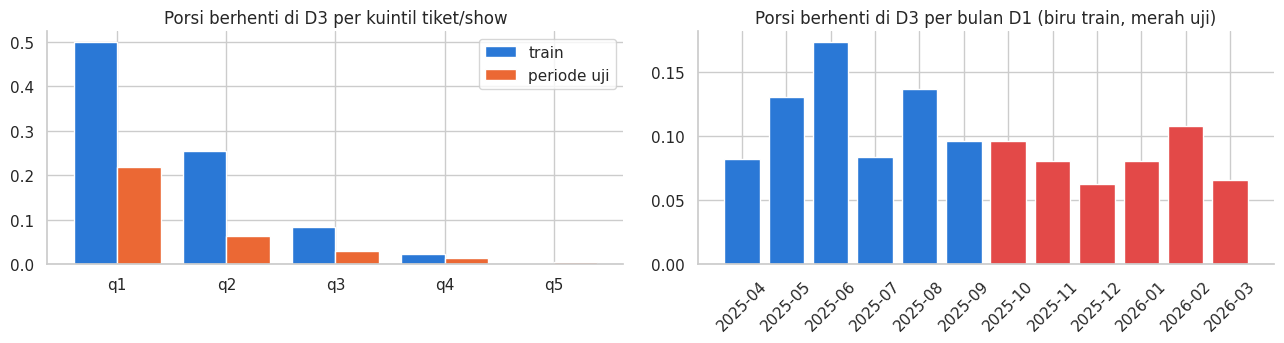

In [15]:
DA = PA.assign(z=PA.y == 0, tps=PA.s * 2 / (PA.sh1 + PA.sh2).clip(lower=1))
DB = PB.assign(z=PB.y == 0, tps=PB.s * 2 / (PB.sh1 + PB.sh2).clip(lower=1))
q = pd.qcut(pd.concat([DA.tps, DB.tps]), 5)
qa, qb = q.iloc[:len(DA)].values, q.iloc[len(DA):].values
tq = pd.DataFrame({'train_drop_D3': DA.z.groupby(qa, observed=False).mean(), 'test_drop_D3': DB.z.groupby(qb, observed=False).mean(),
                   'train_n': pd.Series(qa).value_counts(), 'test_n': pd.Series(qb).value_counts()})
display(tq.round(3))
zm = pd.concat([DA.assign(m=DA.d1.dt.to_period('M')), DB.assign(m=DB.d1.dt.to_period('M'))]).groupby('m').z.mean()
print('D3 stop rate by release month:', zm.round(3).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
xx = np.arange(len(tq))
ax[0].bar(xx - .2, tq.train_drop_D3, .4, label='train'); ax[0].bar(xx + .2, tq.test_drop_D3, .4, label='periode uji')
ax[0].set_xticks(xx, [f'q{i + 1}' for i in xx]); ax[0].set(title='Porsi berhenti di D3 per kuintil tiket/show'); ax[0].legend()
ax[1].bar(zm.index.astype(str), zm.values, color=[PAL[0] if str(m) < '2025-10' else PAL[7] for m in zm.index])
ax[1].set(title='Porsi berhenti di D3 per bulan D1 (biru train, merah uji)'); ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'pull_policy.png'); plt.show()

#### Insights

> Pada tiket per show yang sama, porsi pasangan yang berhenti di D3 di periode uji hanya sekitar setengah sampai seperempat porsi train, di setiap bulan uji, termasuk November dan Desember yang level pasarnya setara bulan-bulan train. Ini bukan efek musim dan bukan data bolong (pola lubang D1 sampai D3 sama), melainkan bioskop di periode uji mempertahankan film pada tingkat penonton yang lebih rendah. Odds pencopotan di D3 sekitar 0,27 kali train, stabil lintas bulan.

> Semua model yang dilatih di train mewarisi kebijakan lama yang lebih cepat mencopot, kandidat kuat penyebab offset leaderboard yang sama di v2 dan v3. Namun di train, kecenderungan mencopot di D3 hampir tidak memprediksi pencopotan D4 sampai D10 (korelasi 0,13 lintas klaster dan bulan), sehingga besarnya pergeseran di horizon target tidak bisa dipastikan. Porsi yang diterapkan dipilih dengan analisis keputusan di Bagian 8.

---

# Feature Engineering <a name="7"></a>

---

Satu fungsi `build` dipanggil identik untuk sampel simulasi dan data uji. Fitur hanya memakai informasi yang tersedia pada D3: riwayat D1 sampai D3, kalender resmi, jadwal rilis film lain yang terlihat di jendela D1 sampai D3 masing-masing, statistik klaster dari masa lalu, dan metadata film.

## Data Eksternal: Kalender Resmi

Hanya sumber yang publik paling lambat 30 September 2025 yang dipakai, seluruhnya fakta kalender pemerintah.

| Sumber | Penerbit | Tanggal terbit | Dipakai untuk |
| :--- | :--- | :--- | :--- |
| [SKB 3 Menteri Libur Nasional dan Cuti Bersama 2025](https://www.kemenkopmk.go.id/skb-3-menteri-libur-nasional-dan-cuti-bersama-tahun-2025) | Kemenko PMK | Oktober 2024 (revisi Agustus 2025) | cuti bersama 2025 |
| [SKB 3 Menteri Libur Nasional dan Cuti Bersama 2026](https://setneg.go.id/baca/index/inilah_skb_3_menteri_libur_nasional_dan_cuti_bersama_2026) | Kemensetneg | 19 September 2025 | cuti bersama 2026; 1 Syawal 1447 H = 21 Maret 2026 |
| [Kalender Pendidikan DKI Jakarta 2024/2025](https://tirto.id/kalender-pendidikan-dki-jakarta-tahun-2024-2025-link-unduh-pdf-g1vR) | Disdik DKI via Tirto | 2024 | libur 28 Juni sampai 12 Juli 2025 |
| [Kalender Pendidikan DKI Jakarta 2025/2026 (Kepdis 89/2025)](https://news.detik.com/berita/d-8049756/kalender-pendidikan-semester-ganjil-2025-2026-jakarta-cek-tanggal-pentingnya) | Disdik DKI via Detik | 7 Agustus 2025 | libur 22 sampai 31 Desember 2025 |
| [SE Kadisdik Jabar 21808/PK.02.01.05/Sekre, Pedoman Kalender Pendidikan 2024/2025](https://mmc.tirto.id/documents/2024/06/24/2479-surat-plh-kadisdik-jabar-kalender-pendidikan-2024-2025-1-14062024-025316-signed.pdf) | Disdik Jawa Barat | 10 Juni 2024 | Jawa Barat: libur akhir tahun pelajaran 30 Juni sampai 12 Juli 2025 |
| [SE Kadisdik Jabar 14995/TU.03/PSMA, Pedoman Kalender Pendidikan 2025/2026](https://www.komunitasbelajar.id/2025/06/kalender-pendidikan-provinsi-jawa-barat.html) ([turunan Disdik Ciamis, Juli 2025](https://disdik.ciamiskab.go.id/storage/2025/07/Kaldik_2025-2026_SD-SMP_DISDIK_FIX.pdf)) | Disdik Jawa Barat | 20 Juni 2025 | Jawa Barat: libur semester ganjil 29 Desember 2025 sampai 10 Januari 2026 |

Ramadan 1447 H (19 Februari sampai 20 Maret 2026) diturunkan dari 1 Syawal pada SKB 2026 dikurangi 30 hari.

## Pengali Kalender Struktural

Nilai kalender $c(t)$ = profil hari, dinaikkan ke level akhir pekan pada libur nasional atau cuti bersama di luar Ramadan (cuti bersama akhir Ramadan adalah masa mudik), dan dikali 1,15 pada hari kerja libur sekolah. Pengali target $c_{mult} = c(t) / \overline{c(D1..D3)}$.

Kalender sekolah DKI dipakai untuk semua klaster kecuali Jawa Barat (22% baris uji), yang memakai kalender Disdik Jabar. Provinsi besar lain yang dicek (Banten, Jawa Tengah, Jawa Timur, DIY, Bali, Lampung, Sulawesi Selatan) libur 20 atau 22 Desember sampai 1 sampai 4 Januari: jendela hari kerja (Senin sampai Kamis) libur sekolahnya sama dengan DKI, karena 25 dan 26 Desember serta 1 Januari sudah libur nasional atau cuti bersama. Jawa Barat berbeda: 22 sampai 24 Desember masih hari sekolah, sedangkan 5 sampai 9 Januari libur. Di periode latih, jendela hari kerja Jawa Barat (30 Juni sampai 12 Juli) identik dengan DKI: $c_{mult}$ latih tidak berubah, hanya flag `t_school` pada akhir pekan 28 sampai 29 Juni (202 baris latih) yang berbeda.

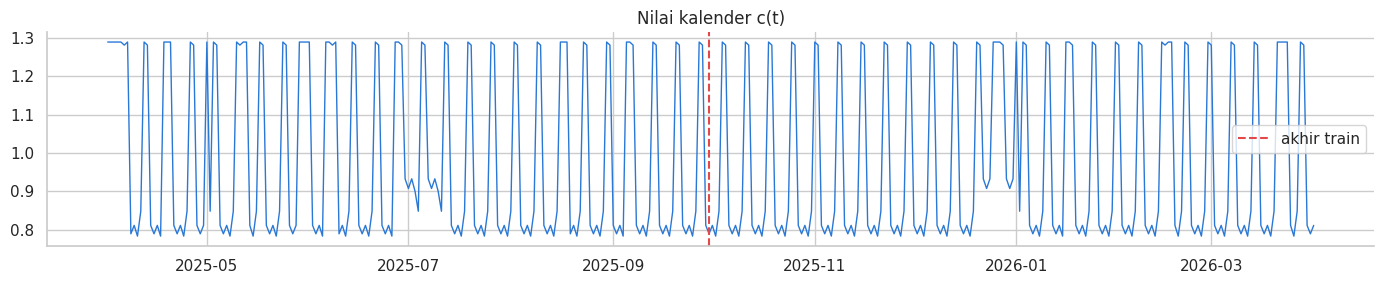

In [16]:
SCHOOL_BREAKS = [('2025-06-28', '2025-07-12'), ('2025-12-22', '2025-12-31')]
JABAR_BREAKS = [('2025-06-30', '2025-07-12'), ('2025-12-29', '2026-01-10')]
JABAR_CITIES = ['BOGOR', 'BEKASI', 'BANDUNG', 'DEPOK', 'CIKARANG', 'KARAWANG', 'CIREBON', 'GARUT', 'TASIKMALAYA',
                'SUMEDANG', 'CIANJUR', 'INDRAMAYU']
CUTI_BERSAMA = pd.to_datetime(['2025-04-02', '2025-04-03', '2025-04-04', '2025-04-07', '2025-05-13', '2025-05-30',
                               '2025-06-09', '2025-08-18', '2025-12-26', '2026-02-16', '2026-03-18', '2026-03-20',
                               '2026-03-23', '2026-03-24'])
RAMADAN = ('2026-02-19', '2026-03-20')


def calendar(hol, breaks=SCHOOL_BREAKS):
    c = hol.rename(columns={'date': 'date_show'})[['date_show', 'holiday_tipe']].copy()
    c['dow'] = c.date_show.dt.dayofweek
    c['is_hol'] = ((c.holiday_tipe == 'holiday') | c.date_show.isin(CUTI_BERSAMA)).astype(int)
    c['school'] = 0
    for a, b in breaks:
        c.loc[c.date_show.between(a, b), 'school'] = 1
    c['ramadan'] = c.date_show.between(*RAMADAN).astype(int)
    base = CFG.DOW_PROF[c.dow]
    base = np.where((c.school == 1) & (c.dow < 4), base * CFG.SCHOOL_WD, base)
    c['cal'] = np.where((c.is_hol == 1) & (c.ramadan == 0), np.maximum(base, CFG.HOL_LEVEL), base)
    return c.drop(columns='holiday_tipe').set_index('date_show')


CAL = calendar(hol)
CAL_JB = calendar(hol, JABAR_BREAKS)
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(CAL.index, CAL.cal, lw=1)
ax.axvline(CFG.TRAIN_END, color=PAL[7], ls='--', label='akhir train')
ax.set(title='Nilai kalender c(t)'); ax.legend()
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'cal_value.png'); plt.show()

## Fungsi Build Fitur

Kelompok fitur: (1) bentuk kurva pasangan D1 sampai D3, (2) agregat film nasional dan pangsa format, (3) kalender target dan riwayat, (4) jadwal rilis film lain, termasuk film baru yang dibuka di klaster yang sama pada tanggal target (terlihat di jendela D1 sampai D3 film tersebut), (5) ukuran klaster dan harga kota, (6) metadata film, (7) level relatif pasar (median film yang rilis 28 hari sebelumnya, gabungan jendela D1 sampai D3 train dan uji).

In [17]:
GENRES = ['Horror', 'Drama', 'Action', 'Comedy', 'Romance', 'Animation', 'Family', 'Thriller', 'Mystery']
RATING = {'Semua Umur': 0, 'Remaja': 1, 'Dewasa': 2, 'Dewasa 21': 3}


def visible_windows(tx, d1):
    x = tx.merge(d1.rename('d1'), left_on='movie_title', right_index=True)
    return x[(x.date_show >= x.d1) & (x.date_show <= x.d1 + pd.Timedelta(days=2))].drop(columns='d1')


def film_table(vis):
    g = vis.groupby('movie_title')
    return pd.DataFrame({'d1': g.date_show.min(), 'occ': g.occupation_rate.mean(),
                         'tps': g.total_ticket.sum() / g.total_show.sum().clip(lower=1),
                         'logT': np.log1p(g.total_ticket.sum() / 3),
                         'lpc': np.log1p(g.total_ticket.sum() / 3 / g.cinema_ids.nunique().clip(lower=1))})


def make_ctx(visible, size_tx, market):
    rel = visible.assign(base=base_title(visible.movie_title)).groupby('base').agg(
        d1=('date_show', 'min'), tix=('total_ticket', 'sum')).reset_index()
    rel['tix'] /= 3
    cs = size_tx.groupby('cinema_ids').total_ticket.sum() / size_tx.groupby('cinema_ids').date_show.nunique()
    nf = size_tx.groupby(['cinema_ids', 'date_show']).movie_title.nunique().groupby('cinema_ids').mean()
    csh = size_tx.groupby(['cinema_ids', 'date_show']).total_show.sum().groupby('cinema_ids').median()
    return dict(releases=rel, market=market, visible=visible, cin_size=np.log10(cs), cin_nfilms=nf, cin_shows=csh)


def cinema_comp(X, vis, cin_shows):
    v = vis.assign(base=base_title(vis.movie_title))
    agg = v.groupby(['cinema_ids', 'date_show', 'base']).agg(sh=('total_show', 'sum'), tx=('total_ticket', 'sum')).reset_index()
    m = X[['cinema_ids', 'date_show']].assign(base=base_title(X.movie_title)).reset_index().merge(
        agg, on=['cinema_ids', 'date_show'], how='left', suffixes=('', '_o'))
    m = m[m.base != m.base_o]
    g = m.groupby('index').agg(c_new_n=('base_o', 'nunique'), c_new_sh=('sh', 'sum'), c_new_tx=('tx', 'sum'))
    X = X.join(g).fillna({'c_new_n': 0, 'c_new_sh': 0, 'c_new_tx': 0})
    X['c_new_sh_rel'] = X.c_new_sh / X.cinema_ids.map(cin_shows).fillna(X.c_new_sh.median() + 1)
    X['c_new_sh_vs_own'] = X.c_new_sh / X.sh3.clip(lower=1)
    X['c_new_tx_vs_own'] = np.log1p(X.c_new_tx) - np.log1p(X.y3)
    return X


def open_count(X, rel):
    d = np.sort(rel.d1.values.astype('datetime64[D]'))
    a = np.searchsorted(d, X.d1.values.astype('datetime64[D]'), side='right')
    b = np.searchsorted(d, X.date_show.values.astype('datetime64[D]'), side='right')
    return b - a


def build(hh, tgt, ctx):
    mv = movies.set_index('original_title')
    d1 = hh.groupby('movie_title').date_show.min().rename('d1')
    hh = hh.join(d1, on='movie_title')
    hh['d'] = (hh.date_show - hh.d1).dt.days + 1
    piv = lambda v, p: hh.pivot_table(index=KEY, columns='d', values=v, fill_value=0).reindex(columns=[1, 2, 3], fill_value=0).add_prefix(p)
    P = pd.concat([piv('total_ticket', 'y'), piv('total_show', 'sh')], axis=1)
    P['mean3'] = P[['y1', 'y2', 'y3']].mean(axis=1)
    P['scale'] = P.mean3.clip(lower=1)
    P['log_s'] = np.log1p(P.mean3)
    for i in (1, 2, 3):
        P[f'p{i}'] = P[f'y{i}'] / P.scale
    P['n_hist'] = (P[['y1', 'y2', 'y3']] > 0).sum(axis=1)
    P['sh_trend'] = P.sh3 / P[['sh1', 'sh2']].max(axis=1).clip(lower=1)
    P = P.reset_index()

    Fd = hh.groupby(['movie_title', 'd']).agg(T=('total_ticket', 'sum'), nc=('cinema_ids', 'nunique')).unstack().fillna(0)
    Fd.columns = [f'f{a}{b}' for a, b in Fd.columns]
    Fd = Fd.reindex(columns=[f'f{a}{b}' for a in ['T', 'nc'] for b in (1, 2, 3)], fill_value=0)
    Fm = Fd[['fT1', 'fT2', 'fT3']].mean(axis=1).clip(lower=1)
    for i in (1, 2, 3):
        Fd[f'fp{i}'] = Fd[f'fT{i}'] / Fm
    ncmax = Fd[['fnc1', 'fnc2', 'fnc3']].max(axis=1).clip(lower=1)
    Fd['f_logT'] = np.log1p(Fm)
    Fd['f_nc_trend'] = Fd.fnc3 / Fd.fnc1.clip(lower=1)
    Fd['f_occ'] = hh.groupby('movie_title').occupation_rate.mean()
    h3 = hh[hh.d == 3].groupby('movie_title')
    Fd['f_tps3'] = h3.total_ticket.sum() / h3.total_show.sum()
    Fd = Fd.join(d1)
    Fd['base'] = base_title(pd.Series(Fd.index, index=Fd.index))
    Fd['fmt'] = fmt(pd.Series(Fd.index, index=Fd.index)).map({'2D': 0, '3D': 1, 'IMAX 2D': 2, 'IMAX 3D': 3})
    bT = hh.assign(base=base_title(hh.movie_title)).groupby('base').total_ticket.sum() / 3
    Fd['fmt_share'] = np.log1p(Fm) - np.log1p(Fd.base.map(bT))
    Fd['d1_dow'] = Fd.d1.dt.dayofweek
    m = mv.reindex(Fd.base)
    Fd['rating'] = m.age_rating.map(RATING).values
    for g_ in GENRES:
        Fd[f'g_{g_}'] = m.genre.fillna('').str.contains(g_).astype(int).values
    Fd['n_genre'] = m.genre.fillna('').str.count(',').values + 1
    Fd['n_cast'] = m.casts.fillna('').str.count(',').values + 1
    rel = ctx['releases']
    Fd['comp_n'] = [((rel.base != r.base) & (rel.d1 > r.d1) & (rel.d1 <= r.d1 + pd.Timedelta(days=9))).sum() for _, r in Fd.iterrows()]
    Fd['f_share_cohort'] = np.log1p(Fd.base.map(bT)) - np.log1p(Fd.d1.map(rel.groupby('d1').tix.sum()))
    mk = ctx['market']
    win = lambda t: mk[(mk.d1 < t) & (mk.d1 >= t - pd.Timedelta(days=28))]
    Fd[['mk_occ', 'mk_tps', 'mk_logT', 'mk_lpc']] = [win(t)[['occ', 'tps', 'logT', 'lpc']].median().tolist() for t in Fd.d1]
    Fd['occ_rel'] = Fd.f_occ / Fd.mk_occ
    Fd['tps_rel'] = Fd.f_tps3 / Fd.mk_tps
    Fd['logT_rel'] = Fd.f_logT - Fd.mk_logT
    Fd['film_pc_vs_mkt'] = np.log1p(Fm / ncmax) - Fd.mk_lpc

    X = tgt.merge(P, on=KEY, how='left').merge(Fd.drop(columns=['base']), left_on='movie_title', right_index=True, how='left')
    X['h'] = (X.date_show - X.d1).dt.days + 1
    jb = (X.city_name.isin(JABAR_CITIES) & CFG.REGIONAL_CAL).values
    cal_at = lambda dates, col: np.where(jb, CAL_JB[col].reindex(dates).values, CAL[col].reindex(dates).values)
    X['dow'] = X.date_show.dt.dayofweek.values
    X['t_hol'], X['t_school'], X['t_ramadan'] = cal_at(X.date_show, 'is_hol'), cal_at(X.date_show, 'school'), cal_at(X.date_show, 'ramadan')
    ch = np.stack([cal_at(X.d1 + pd.Timedelta(days=k), 'cal') for k in range(3)], 1)
    X['cal_mult'] = cal_at(X.date_show, 'cal') / ch.mean(1)
    X['hol_in_hist'] = np.stack([cal_at(X.d1 + pd.Timedelta(days=k), 'is_hol') for k in range(3)], 1).sum(1)
    X['n_comp_open'] = open_count(X, rel)
    X = cinema_comp(X, ctx['visible'], ctx['cin_shows'])
    X['share'] = X.log_s - np.log1p(X[['fT1', 'fT2', 'fT3']].mean(axis=1) / X.fnc3.clip(lower=1))
    X['pair_vs_mkt'] = X.log_s - X.mk_lpc
    X['p3_rel'] = X.p3 - X.fp3
    X['p1_rel'] = X.p1 - X.fp1
    X['cin_size'] = X.cinema_ids.map(ctx['cin_size'])
    X['cin_nfilms'] = X.cinema_ids.map(ctx['cin_nfilms'])
    X['cin_new'] = X.cin_size.isna().astype(int)
    pr = price.pivot(index='city_name', columns='price_day', values='ceil')
    X['price_wkd'] = X.city_name.map(pr.Weekday)
    X['price_prem'] = X.city_name.map(pr.Weekend / pr.Weekday)
    return X


def name_set(v):
    return {t.strip().lower() for t in str(v).split(',') if t.strip() and t.strip().lower() not in ('-', 'nan')}


def add_meta(X, rel_all):
    mv = movies.set_index('original_title')
    base = base_title(X.movie_title)
    up = base.str.upper()
    X['has_number'] = up.str.contains(r'\b(?:\d+|II|III|IV)\b', regex=True).astype(int).values
    X['has_subtitle'] = up.str.contains(':', regex=False).astype(int).values
    X['is_reissue'] = X.movie_title.str.upper().str.contains('REISSUE|RE-RELEASE', regex=True).astype(int).values
    casts = {b: name_set(mv.casts.get(b, '')) for b in set(base) | set(rel_all.index)}
    ov = {}
    for b, d in X.groupby(base.values).d1.min().items():
        earlier = set().union(*[casts.get(g, set()) for g in rel_all.index[(rel_all < d).values]])
        ov[b] = len(casts.get(b, set()) & earlier)
    X['cast_overlap'] = base.map(ov).values
    X['cast_overlap_share'] = X.cast_overlap / base.map({b: max(len(c), 1) for b, c in casts.items()}).values
    return X

Fitur dibangun untuk film rilis luas, film rilis terbatas (hanya latih), dan data uji. Tiga pemeriksaan wajib: jumlah baris tetap, urutan `id` uji tetap, dan skala sama persis dengan fungsi `hitung_skala` resmi.

In [18]:
vis_tr = visible_windows(train, D_wide)
market = pd.concat([film_table(vis_tr), film_table(hist)])
ctx_tr = make_ctx(vis_tr, train, market)
Xtr = build(hs, ts, ctx_tr)
Xlim = build(hl, tl, ctx_tr)
ctx_te = make_ctx(hist, train, market)
Xte = build(hist, test, ctx_te)

assert len(Xtr) == len(ts) and len(Xte) == len(test) and (Xte.id.values == test.id.values).all()
ref = Xte.join(pair_scale(hist), on=KEY, rsuffix='_ref')
assert np.allclose(ref.scale, ref.scale_ref)

BASE_FEATS = ['log_s', 'p1', 'p2', 'p3', 'n_hist', 'sh_trend', 'fnc1', 'fnc2', 'fnc3', 'fp1', 'fp2', 'fp3', 'f_logT',
              'f_nc_trend', 'fmt', 'fmt_share', 'd1_dow', 'rating'] + [f'g_{g_}' for g_ in GENRES] + [
              'n_genre', 'n_cast', 'comp_n', 'f_share_cohort', 'h', 'dow', 't_hol', 't_school', 't_ramadan', 'cal_mult',
              'hol_in_hist', 'n_comp_open', 'share', 'p3_rel', 'p1_rel', 'cin_size', 'cin_nfilms', 'cin_new',
              'price_wkd', 'price_prem']
COMP_FEATS = ['c_new_n', 'c_new_sh', 'c_new_sh_rel', 'c_new_sh_vs_own', 'c_new_tx_vs_own']
META_FEATS = ['has_number', 'has_subtitle', 'is_reissue', 'cast_overlap', 'cast_overlap_share']
FEATS = BASE_FEATS
ZFEATS = FEATS + COMP_FEATS
show_t = train.set_index(KEY + ['date_show']).total_show
for X_ in (Xtr, Xlim):
    X_['sh_t'] = show_t.reindex(pd.MultiIndex.from_frame(X_[KEY + ['date_show']])).fillna(0).values
REL_ALL = pd.concat([ctx_tr['releases'], ctx_te['releases']]).groupby('base').d1.min()
for X_ in (Xtr, Xlim, Xte):
    add_meta(X_, REL_ALL)
jb_changed = Xte.t_school.values != CAL.school.reindex(Xte.date_show).values
print(f'West Java calendar: {jb_changed.sum()} test rows change school flag ({jb_changed.mean():.2%}); train rows changed: '
      f'{int((Xtr.t_school.values != CAL.school.reindex(Xtr.date_show).values).sum())}')
print('official metadata, share of test rows:', Xte[['has_number', 'has_subtitle', 'is_reissue']].mean().round(3).to_dict(),
      '| cast_overlap > 0:', round(float((Xte.cast_overlap > 0).mean()), 3))
print(f'train {len(Xtr)} rows | limited extra {len(Xlim)} | test {len(Xte)} | features {len(FEATS)}')
display(pd.DataFrame({'train_median': Xtr[['log_s', 'f_logT', 'pair_vs_mkt', 'film_pc_vs_mkt', 'share']].median(),
                      'test_median': Xte[['log_s', 'f_logT', 'pair_vs_mkt', 'film_pc_vs_mkt', 'share']].median()}).round(3))

West Java calendar: 1134 test rows change school flag (1.56%); train rows changed: 202
official metadata, share of test rows: {'has_number': 0.122, 'has_subtitle': 0.189, 'is_reissue': 0.0} | cast_overlap > 0: 0.767
train 56372 rows | limited extra 1435 | test 72611 | features 47


,train_median,test_median
log_s,5.204,4.529
f_logT,9.974,9.450
pair_vs_mkt,0.019,-0.123
film_pc_vs_mkt,0.353,0.286
share,-0.379,-0.435


## Verifikasi Drift: Adversarial Validation

Classifier dilatih membedakan baris simulasi dari baris uji dengan fold dikelompokkan per film (split acak memberi AUC palsu 1,0 karena fitur level film konstan dalam satu film).

In [19]:
def adv_auc(cols):
    A = pd.concat([Xtr[cols].assign(t=0, g=Xtr.movie_title), Xte[cols].assign(t=1, g=Xte.movie_title)], ignore_index=True)
    oof = np.zeros(len(A))
    for a, b in StratifiedGroupKFold(5, shuffle=True, random_state=CFG.SEED).split(A, A.t, A.g):
        m = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=CFG.SEED, verbose=-1)
        oof[b] = m.fit(A.iloc[a][cols], A.t.iloc[a]).predict_proba(A.iloc[b][cols])[:, 1]
    return roc_auc_score(A.t, oof)


shape_cols = ['p1', 'p2', 'p3', 'fp1', 'fp3', 'share', 'sh_trend', 'd1_dow', 'n_hist']
print(f"AUC shape features only:         {adv_auc(shape_cols):.3f}")
print(f"AUC + absolute level (log_s, f_logT): {adv_auc(shape_cols + ['log_s', 'f_logT']):.3f}")
print(f"AUC + market-relative level:     {adv_auc(shape_cols + ['pair_vs_mkt', 'film_pc_vs_mkt']):.3f}")

AUC shape features only:         0.510
AUC + absolute level (log_s, f_logT): 0.544
AUC + market-relative level:     0.479


#### Insights

> Fitur bentuk kurva tidak bisa membedakan train dan uji (AUC sekitar 0,51). Level absolut menaikkan AUC (sekitar 0,54) karena pasar uji lebih sepi, sedangkan level relatif pasar tidak menaikkannya (sekitar 0,48): median `log_s` bergeser 0,67 tetapi `pair_vs_mkt` hanya 0,14. Varian `both` memanfaatkan hal ini.

---

# Modeling <a name="8"></a>

---

Bagian ini disusun sebagai **tangga ablation dengan aturan adopsi yang ditulis sebelum hasil terlihat**, mengikuti audit eksperimen 5 Oktober 2026. Satu baseline bersih menjadi pembanding tetap, setiap kandidat hanya mengubah satu hal, dan foundation model baru dievaluasi setelah konfigurasi LightGBM terpilih. Empat lensa dihitung untuk setiap konfigurasi: (1) **grouped CV label asli** dengan bobot komposisi uji (bucket skala x hari pertama laku), lensa utama; (2) **backtest temporal** untuk film rilis Juli, Agustus, dan September dengan data latih yang labelnya sudah lengkap sebelum cutoff (kalender dan fitur jadwal tetap dibangun sekali dari seluruh periode, jadi ini bukan pipeline kausal ketat); (3) **stabilitas per fold**; (4) **dunia $\kappa$** sebagai uji stres pergeseran kebijakan pencopotan, dengan generator tetap. Ketiga lensa terakhir dihitung dari train periode April sampai September, sehingga tidak dianggap bukti independen. $\lambda = 0{,}5$ dan bobot hurdle 0,75 dibekukan sebagai baseline; sensitivitas $\lambda$ hanya dilaporkan.

## Lensa Validasi

Fold dikelompokkan per judul dasar film. Bobot `TW` menyamakan porsi setiap sel (bucket skala x hari pertama laku) dengan data uji; bobot lama per bucket skala (`TW_OLD`) tetap dilaporkan sebagai pembanding.

In [20]:
groups = base_title(Xtr.movie_title).values
ug = np.array(sorted(set(groups)))
fold_of = dict(zip(ug, np.random.RandomState(CFG.SEED).permutation(len(ug)) % CFG.N_FOLDS))
FOLD = np.array([fold_of[g_] for g_ in groups])
y, s, cm, hh_ = Xtr.total_ticket.values, Xtr.scale.values, Xtr.cal_mult.values, Xtr.h.values

bt = pd.cut(Xtr.scale, CFG.TW_BINS)
tw = bt.map(pd.cut(Xte.scale, CFG.TW_BINS).value_counts(normalize=True) / bt.value_counts(normalize=True)).astype(float).values
TW_OLD = tw / tw.mean()
fday = lambda D: pd.Series(np.where(D.y1 > 0, 1, np.where(D.y2 > 0, 2, 3)), index=D.index)
cell = lambda D: pd.cut(D.scale, CFG.TW_BINS).astype(str) + '|' + fday(D).astype(str)
tw = cell(Xtr).map(cell(Xte).value_counts(normalize=True) / cell(Xtr).value_counts(normalize=True)).fillna(0).astype(float).values
TW = tw / tw.mean()
print('late starters (first sale on D3): old weights', round(float(TW_OLD[fday(Xtr) == 3].sum() / len(TW)), 3),
      '| new weights', round(float(TW[fday(Xtr) == 3].sum() / len(TW)), 3), '| test', round(float((fday(Xte) == 3).mean()), 3))


def score(p, name, yy=None):
    yy = y if yy is None else yy
    e = np.abs(yy - p) / s
    r = dict(model=name, MASE=e.mean(), TW_MASE=np.average(e, weights=TW), TW_OLD=np.average(e, weights=TW_OLD),
             small=e[s <= 20].mean(), big=e[s > 200].mean())
    print(f"{name:40s} MASE {r['MASE']:.4f} | TW-MASE {r['TW_MASE']:.4f} (old {r['TW_OLD']:.4f}) | s<=20 {r['small']:.4f} | s>200 {r['big']:.4f}")
    return r


def train_part(k):
    Xa = Xtr[FOLD != k]
    return pd.concat([Xa, Xlim], ignore_index=True) if CFG.USE_LIMITED else Xa


results = []
rc = y / s / cm
oof_base = np.zeros(len(Xtr))
for k in range(CFG.N_FOLDS):
    a, b = FOLD != k, FOLD == k
    med = pd.Series(rc[a]).groupby([hh_[a], Xtr.d1_dow.values[a]]).median()
    oof_base[b] = med.reindex(pd.MultiIndex.from_arrays([hh_[b], Xtr.d1_dow.values[b]])).fillna(np.median(rc[a])).values * cm[b] * s[b]
results.append(score(np.zeros(len(Xtr)), 'zero'))
results.append(score(oof_base, 'median r/c by (h, D1 dow)'))

late starters (first sale on D3): old weights 0.042 | new weights 0.018 | test 0.018
zero                                     MASE 0.5881 | TW-MASE 0.5394 (old 0.6104) | s<=20 0.8820 | s>200 0.6309
median r/c by (h, D1 dow)                MASE 0.4002 | TW-MASE 0.4330 (old 0.4951) | s<=20 0.9822 | s>200 0.3279


In [21]:
for Pp in (PA, PB):
    c3 = np.stack([CAL.cal.reindex(Pp.d1 + pd.Timedelta(days=k)).values for k in range(3)], 1)
    Pp['cm'] = c3[:, 2] / c3[:, :2].mean(1)
PCOLS = ['q1', 'q2', 'log_s', 'sh1', 'sh2', 'sh_tr', 'occ2', 'f_tr', 'f_log', 'f_nc', 'cm', 'd1_dow']
clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=100, verbose=-1,
                         deterministic=True, force_row_wise=True, random_state=CFG.SEED).fit(PA[PCOLS], PA.y == 0)
logit = lambda p: np.log(p / (1 - p))
sigm = lambda t: 1 / (1 + np.exp(-t))
pB0 = np.clip(clf.predict_proba(PB[PCOLS])[:, 1], 1e-4, 1 - 1e-4)
zB = (PB.y == 0).values
grid = np.linspace(-4, 2, 601)
nll = lambda p, z, a: -np.mean(z * np.log(sigm(logit(p) + a)) + (1 - z) * np.log(1 - sigm(logit(p) + a)))
PULL_A = float(grid[np.argmin([nll(pB0, zB, a) for a in grid])])
mon = PB.d1.dt.to_period('M').astype(str).values
per_month = {m: round(float(grid[np.argmin([nll(pB0[mon == m], zB[mon == m], a) for a in grid])]), 2) for m in sorted(set(mon))}
print(f'pull-odds shift a = {PULL_A:.3f} (odds x {np.exp(PULL_A):.2f}); mean p0 train-model {pB0.mean():.3f} -> '
      f'shifted {sigm(logit(pB0) + PULL_A).mean():.3f} | observed {zB.mean():.3f}')
print('per test month:', per_month)

pull-odds shift a = -1.320 (odds x 0.27); mean p0 train-model 0.146 -> shifted 0.085 | observed 0.085
per test month: {'2025-10': -1.1, '2025-11': 0.0, '2025-12': -1.87, '2026-01': -1.26, '2026-02': -1.68, '2026-03': -1.87}


## Statistik Klaster Fold-Local

`make_ctx` menghitung ukuran klaster, jumlah film per hari, dan jumlah show dari seluruh train, termasuk transaksi film yang sedang divalidasi. Di bawah, statistik dihitung ulang per fold tanpa seluruh transaksi film fold validasi, dan per cutoff temporal hanya dari transaksi sebelum cutoff. Data uji tetap memakai seluruh train, yang memang masa lalu bagi film uji. Perbandingan B0 (statistik global, seperti v8) dan B1 (fold-local) mengukur besar kebocoran ini, bukan mengasumsikannya kecil.

In [22]:
def cin_stats(tx):
    cs = tx.groupby('cinema_ids').total_ticket.sum() / tx.groupby('cinema_ids').date_show.nunique()
    nf = tx.groupby(['cinema_ids', 'date_show']).movie_title.nunique().groupby('cinema_ids').mean()
    csh = tx.groupby(['cinema_ids', 'date_show']).total_show.sum().groupby('cinema_ids').median()
    return np.log10(cs), nf, csh


def with_cin(X, stats):
    cs, nf, csh = stats
    X = X.copy()
    X['cin_size'] = X.cinema_ids.map(cs)
    X['cin_nfilms'] = X.cinema_ids.map(nf)
    X['cin_new'] = X.cin_size.isna().astype(int)
    X['c_new_sh_rel'] = X.c_new_sh / X.cinema_ids.map(csh).fillna(X.c_new_sh.median() + 1)
    return X


TRAIN_BASE = base_title(train.movie_title)
STATS_ALL = cin_stats(train)
assert np.allclose(with_cin(Xtr, STATS_ALL).cin_size.fillna(-9), Xtr.cin_size.fillna(-9))
STATS_FOLD = {k: cin_stats(train[~TRAIN_BASE.isin(set(groups[FOLD == k]))]) for k in range(CFG.N_FOLDS)}
chg = np.concatenate([(with_cin(Xtr[FOLD == k], STATS_FOLD[k]).cin_size - Xtr.cin_size[FOLD == k]).abs().values for k in range(CFG.N_FOLDS)])
rk = np.mean([pd.Series(with_cin(Xtr[FOLD == k], STATS_FOLD[k]).cin_size.values).corr(pd.Series(Xtr.cin_size[FOLD == k].values), method='spearman') for k in range(CFG.N_FOLDS)])
print(f'|change| of cin_size on validation rows: median {np.nanmedian(chg):.4f}, p95 {np.nanpercentile(chg, 95):.4f} (log10 tickets per day; '
      f'mostly a level shift from removing ~20% of films) | rank correlation global vs fold-local {rk:.4f}')

|change| of cin_size on validation rows: median 0.0523, p95 0.1237 (log10 tickets per day; mostly a level shift from removing ~20% of films) | rank correlation global vs fold-local 0.9989


## Kandidat A1: Perubahan Show dan Tiket per Show (Nested Cross-Fitting)

Galat terbesar ada pada target positif (84%) dan pada D4 sampai D5 (37%). Tiket pada tanggal target dapat diurai menjadi jumlah show yang dijadwalkan bioskop dan tiket per show. Dua model bantu LightGBM (median) dilatih dari label train: $a_1 = \log(1 + \text{show}_t) - \log(1 + \text{show}_{D3})$ dan $a_2 = \log\frac{y_t + 1}{\text{show}_t + 1} - \log\frac{y_{D3} + 1}{\text{show}_{D3} + 1}$ (hanya baris dengan show). Prediksinya **tidak dikalikan**, karena median show x median tiket per show bukan median tiket. Prediksi itu masuk sebagai fitur `aux_sh`, `aux_tps`, dan `aux_tix` ke model tiket, yang tetap dinilai dengan MASE.

Agar label validasi tidak bocor lewat fitur, pembentukannya bersarang: di setiap fold luar, fitur baris latih berasal dari inner fold (dikelompokkan per film) di dalam bagian latih saja, sedangkan fitur baris validasi berasal dari model bantu yang dilatih pada seluruh bagian latih. Di backtest temporal, model bantu hanya melihat film yang labelnya lengkap sebelum cutoff. Fitur inferensi hanya memakai D1 sampai D3; jumlah show tanggal target tidak pernah menjadi input.

In [23]:
AUX_P = dict(objective='l1', n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=100, feature_fraction=0.7,
             bagging_fraction=0.8, bagging_freq=1, deterministic=True, force_row_wise=True, n_jobs=4, verbose=-1)
AUX_FEATS = ['aux_sh', 'aux_tps', 'aux_tix']


def aux_targets(X):
    a1 = (np.log1p(X.sh_t) - np.log1p(X.sh3)).values
    a2 = (np.log((X.total_ticket + 1) / (X.sh_t + 1)) - np.log((X.y3 + 1) / (X.sh3 + 1))).values
    return a1, a2, (X.sh_t > 0).values


def aux_fit(A, feats):
    a1, a2, ok = aux_targets(A)
    m1 = lgb.LGBMRegressor(**AUX_P, random_state=CFG.SEED).fit(A[feats], a1)
    m2 = lgb.LGBMRegressor(**AUX_P, random_state=CFG.SEED).fit(A[feats][ok], a2[ok])
    return m1, m2


def aux_predict(models, B, feats):
    return np.column_stack([models[0].predict(B[feats]), models[1].predict(B[feats])])


def add_aux(A, B, feats, inner=4):
    gA = base_title(A.movie_title).values
    ugA = np.array(sorted(set(gA)))
    fi = dict(zip(ugA, np.random.RandomState(CFG.SEED + 1).permutation(len(ugA)) % inner))
    f = np.array([fi[x] for x in gA])
    oofA = np.zeros((len(A), 2))
    for j in range(inner):
        oofA[f == j] = aux_predict(aux_fit(A[f != j], feats), A[f == j], feats)
    full = aux_fit(A, feats)
    out = []
    for X, P in ((A, oofA), (B, aux_predict(full, B, feats))):
        X = X.copy()
        X['aux_sh'], X['aux_tps'] = P[:, 0], P[:, 1]
        X['aux_tix'] = X.aux_sh + X.aux_tps
        out.append(X)
    return out[0], out[1], full


a1_, a2_, ok_ = aux_targets(Xtr)
print(f'aux targets on train-sim: show change median {np.median(a1_):.3f} (share of rows with no show on target date {np.mean(Xtr.sh_t == 0):.3f}) | '
      f'tickets-per-show change median {np.median(a2_[ok_]):.3f}')

aux targets on train-sim: show change median -0.318 (share of rows with no show on target date 0.300) | tickets-per-show change median -0.288


## Mesin Evaluasi

`make_parts` menyiapkan bagian latih dan validasi untuk satu konfigurasi (statistik klaster, metadata, fitur bantu), `run_cv` menjalankan grouped CV, dan `temporal` menjalankan backtest bulanan. Model yang dipakai identik dengan baseline v8: LightGBM L1 (5 seed) ditambah hurdle (klasifier $p_0$ dengan fitur kompetisi klaster dan 19 regresi kuantil bagian positif), dicampur dengan bobot hurdle 0,75 pada $\lambda = 0{,}5$.

In [24]:
LGB_BASE = {k: v for k, v in CFG.LGB_PARAMS.items() if k not in ('objective', 'n_estimators')}
LGB_FAST = {**LGB_BASE, 'n_estimators': 300, 'learning_rate': 0.05}
MONTHS = ['2025-07', '2025-08', '2025-09']


def r_target(Xa):
    return (Xa.total_ticket / Xa.scale / Xa.cal_mult).values


def fit_lgb_all(Xa, feats, zfeats):
    l1 = [lgb.LGBMRegressor(objective='l1', n_estimators=CFG.LGB_PARAMS['n_estimators'], **LGB_BASE, random_state=sd)
          .fit(Xa[feats], r_target(Xa), sample_weight=Xa.cal_mult.values) for sd in CFG.SEEDS]
    zc = lgb.LGBMClassifier(objective='binary', **{**LGB_FAST, 'num_leaves': 31}, random_state=CFG.SEED).fit(Xa[zfeats], Xa.total_ticket == 0)
    pos = Xa[Xa.total_ticket > 0]
    qm = [lgb.LGBMRegressor(objective='quantile', alpha=float(q), **LGB_FAST, random_state=CFG.SEED).fit(pos[feats], r_target(pos))
          for q in CFG.QS]
    return dict(l1=l1, zc=zc, qm=qm)


def predict_lgb_all(m, Xb, feats, zfeats):
    l1 = np.clip(np.mean([mm.predict(Xb[feats]) for mm in m['l1']], 0), 0, None)
    p0 = m['zc'].predict_proba(Xb[zfeats])[:, 1]
    Q = np.sort(np.column_stack([mm.predict(Xb[feats]) for mm in m['qm']]), axis=1)
    return l1, p0, Q


def mixture_median(p0, Q, qs, lam):
    p = sigm(logit(np.clip(p0, 1e-4, 1 - 1e-4)) + lam * PULL_A)
    t = np.clip((0.5 - p) / (1 - p), qs[0], qs[-1])
    val = np.array([np.interp(ti, qs, qi) for ti, qi in zip(t, Q)])
    return np.where(p >= 0.5, 0.0, np.clip(val, 0, None))


def lgb_mix(l1, p0, Q, lam=None):
    lam = CFG.LAMBDA if lam is None else lam
    return (1 - CFG.HURDLE_W) * l1 + CFG.HURDLE_W * mixture_median(p0, Q, CFG.QS, lam)


def make_parts(Xa, Xb, cfg, stats):
    if cfg['cin'] == 'local':
        Xa, Xb = with_cin(Xa, stats), with_cin(Xb, stats)
    feats = BASE_FEATS + (META_FEATS if cfg['meta'] else [])
    aux_models = None
    if cfg['aux']:
        Xa, Xb, aux_models = add_aux(Xa, Xb, feats)
        feats = feats + AUX_FEATS
    return Xa, Xb, feats, feats + COMP_FEATS, aux_models


def run_cv(cfg):
    oof = dict(l1=np.zeros(len(Xtr)), p0=np.zeros(len(Xtr)), Q=np.zeros((len(Xtr), len(CFG.QS))))
    frames = {}
    for k in range(CFG.N_FOLDS):
        v = FOLD == k
        Xa, Xb, feats, zfeats, _ = make_parts(train_part(k), Xtr[v], cfg, STATS_FOLD[k])
        oof['l1'][v], oof['p0'][v], oof['Q'][v] = predict_lgb_all(fit_lgb_all(Xa, feats, zfeats), Xb, feats, zfeats)
        frames[k] = (Xa, Xb, feats)
    return oof, frames


def temporal(cfg):
    out = {}
    for mth in MONTHS:
        cut = pd.Timestamp(mth + '-01')
        va = (Xtr.d1.dt.strftime('%Y-%m') == mth).values
        ready = lambda X: X[(X.d1 + pd.Timedelta(days=9) < cut).values]
        Xa = pd.concat([ready(Xtr), ready(Xlim)], ignore_index=True) if CFG.USE_LIMITED else ready(Xtr)
        stats = cin_stats(train[train.date_show < cut]) if cfg['cin'] == 'local' else STATS_ALL
        Xa_, Xb_, feats, zfeats, _ = make_parts(Xa, Xtr[va], cfg, stats)
        out[mth] = dict(idx=np.where(va)[0], parts=predict_lgb_all(fit_lgb_all(Xa_, feats, zfeats), Xb_, feats, zfeats),
                        frames=(Xa_, Xb_, feats), n_train_films=base_title(Xa.movie_title).nunique())
    return out

## Aturan Adopsi (Ditulis Sebelum Hasil)

- **B1** (statistik klaster fold-local) menjadi baseline bersih apa pun hasilnya, karena itu koreksi alat ukur. Selisih B0 ke B1 dilaporkan sebagai besar kebocoran statistik klaster.
- Kandidat diadopsi hanya bila **semua** syarat terhadap B1 terpenuhi: (1) TW-MASE grouped CV label asli turun minimal `ABL_MIN_GAIN` (0,0015); (2) rata-rata backtest temporal turun dan tidak ada bulan yang naik lebih dari `ABL_MONTH_TOL` (0,003); (3) membaik di minimal `ABL_MIN_FOLDS` (3) dari 5 fold; (4) TW-MASE dunia $\kappa$ tidak naik lebih dari `ABL_KAPPA_TOL` (0,002).
- Bila kedua kandidat lolos, gabungannya dinilai ulang dengan aturan yang sama; bila gabungan gagal, dipilih kandidat tunggal dengan TW-MASE terbaik. Bila selisihnya tipis dan kesimpulan berubah antar-lensa, versi yang lebih sederhana dipertahankan.
- Dunia $\kappa$ dibangun sekali dari OOF B1 (generator tetap untuk semua konfigurasi): target nol dibatalkan dengan peluang $1 - p_0'/p_0$, $\text{logit}\,p_0' = \text{logit}\,p_0 + \kappa a$, lalu diganti sampel dari distribusi positif B1, dirata-rata atas tiga seed. Dunia ini sintetis, sehingga hanya menjadi uji stres.

In [25]:
CONFIGS = {'B0 global stats (v8)': dict(cin='global', meta=False, aux=False),
           'B1 fold-local stats': dict(cin='local', meta=False, aux=False),
           'A1 + show/attendance': dict(cin='local', meta=False, aux=True),
           'A2 + official metadata': dict(cin='local', meta=True, aux=False)}
RUNS = {}


def run_config(name, cfgx):
    t0 = time.time()
    oof, frames = run_cv(cfgx)
    RUNS[name] = dict(cfg=cfgx, oof=oof, frames=frames, temporal=temporal(cfgx), pred=lgb_mix(oof['l1'], oof['p0'], oof['Q']) * cm * s)
    print(f'{name:28s} done ({time.time() - t0:.0f}s)')


for name, cfgx in CONFIGS.items():
    run_config(name, cfgx)

REF = 'B1 fold-local stats'
WORLDS = []
for sd in range(CFG.KAPPA_SEEDS):
    rng = np.random.default_rng(CFG.SEED + sd)
    p0b, Qb = RUNS[REF]['oof']['p0'], RUNS[REF]['oof']['Q']
    p_sh = sigm(logit(np.clip(p0b, 1e-4, 1 - 1e-4)) + CFG.KAPPA * PULL_A)
    unpull = (y == 0) & (rng.random(len(y)) < 1 - p_sh / np.clip(p0b, 1e-6, None))
    draw = np.array([np.interp(u, CFG.QS, q) for u, q in zip(rng.random(len(y)), Qb)])
    WORLDS.append(np.where(unpull, np.clip(draw, 0, None) * cm * s, y))
print(f'zero rate: real {np.mean(y == 0):.3f} | kappa worlds {np.mean([np.mean(w_ == 0) for w_ in WORLDS]):.3f}')


def temporal_pred(R, lam=None):
    return {m: (t['idx'], lgb_mix(*t['parts'], lam=lam) * cm[t['idx']] * s[t['idx']]) for m, t in R['temporal'].items()}


def lens(p, tpred):
    e = np.abs(y - p) / s
    r = dict(TW=np.average(e, weights=TW), TW_OLD=np.average(e, weights=TW_OLD), MASE=e.mean())
    r.update({f'fold{k}': np.average(e[FOLD == k], weights=TW[FOLD == k]) for k in range(CFG.N_FOLDS)})
    tm = {m: np.average(np.abs(y[i] - pr) / s[i], weights=TW[i]) for m, (i, pr) in tpred.items()}
    r.update({f'temp_{m}': v for m, v in tm.items()})
    r['temporal_mean'] = np.mean(list(tm.values()))
    r['kappa'] = np.mean([np.average(np.abs(w_ - p) / s, weights=TW) for w_ in WORLDS])
    return r


def passes(L, cand, ref=REF):
    a, b = L.loc[cand], L.loc[ref]
    checks = {'tw_gain': b.TW - a.TW >= CFG.ABL_MIN_GAIN,
              'temporal_mean': a.temporal_mean < b.temporal_mean,
              'no_month_worse': max(a[f'temp_{m}'] - b[f'temp_{m}'] for m in MONTHS) <= CFG.ABL_MONTH_TOL,
              'folds': sum(a[f'fold{k}'] < b[f'fold{k}'] for k in range(CFG.N_FOLDS)) >= CFG.ABL_MIN_FOLDS,
              'kappa': a.kappa - b.kappa <= CFG.ABL_KAPPA_TOL}
    return all(checks.values()), checks


L = pd.DataFrame({n: lens(R['pred'], temporal_pred(R)) for n, R in RUNS.items()}).T
display(L.round(4))
print('temporal training films per cutoff:', {m: t['n_train_films'] for m, t in RUNS[REF]['temporal'].items()})
print(f"cluster-statistics leak (B0 - B1, TW): {L.loc['B0 global stats (v8)', 'TW'] - L.loc[REF, 'TW']:+.4f} | "
      f"temporal mean: {L.loc['B0 global stats (v8)', 'temporal_mean'] - L.loc[REF, 'temporal_mean']:+.4f}")

B0 global stats (v8)         done (572s)
B1 fold-local stats          done (572s)
A1 + show/attendance         done (711s)
A2 + official metadata       done (572s)
zero rate: real 0.300 | kappa worlds 0.246


,TW,TW_OLD,MASE,fold0,fold1,fold2,fold3,fold4,temp_2025-07,temp_2025-08,temp_2025-09,temporal_mean,kappa
B0 global stats (v8),0.3326,0.3915,0.3134,0.3892,0.3181,0.3619,0.3984,0.2078,0.3261,0.2902,0.3004,0.3056,0.3433
B1 fold-local stats,0.3319,0.3906,0.3132,0.3885,0.3178,0.3627,0.3962,0.2066,0.3270,0.2889,0.3015,0.3058,0.3427
A1 + show/attendance,0.3321,0.3905,0.3137,0.3839,0.3191,0.3558,0.4029,0.2110,0.3232,0.2853,0.3086,0.3057,0.3436
A2 + official metadata,0.3301,0.3892,0.3106,0.3830,0.3169,0.3650,0.3930,0.2048,0.3229,0.2880,0.3050,0.3053,0.3417


temporal training films per cutoff: {'2025-07': 62, '2025-08': 93, '2025-09': 130}
cluster-statistics leak (B0 - B1, TW): +0.0007 | temporal mean: -0.0002


Keputusan adopsi diterapkan otomatis. Selisih per film (bootstrap 2.000 kali per film, bobot tetap) ikut dicetak agar terlihat apakah perbaikan tersebar atau hanya dari beberapa film.

,adopted,tw_gain,temporal_mean,no_month_worse,folds,kappa,film_delta_ci95,films_better
candidate,,,,,,,,
A1 + show/attendance,False,False,True,False,False,True,"[-0.0034, +0.0032]",59/126
A2 + official metadata,False,True,True,False,True,True,"[-0.0040, +0.0005]",68/126


SELECTED configuration: B1 fold-local stats | features 47


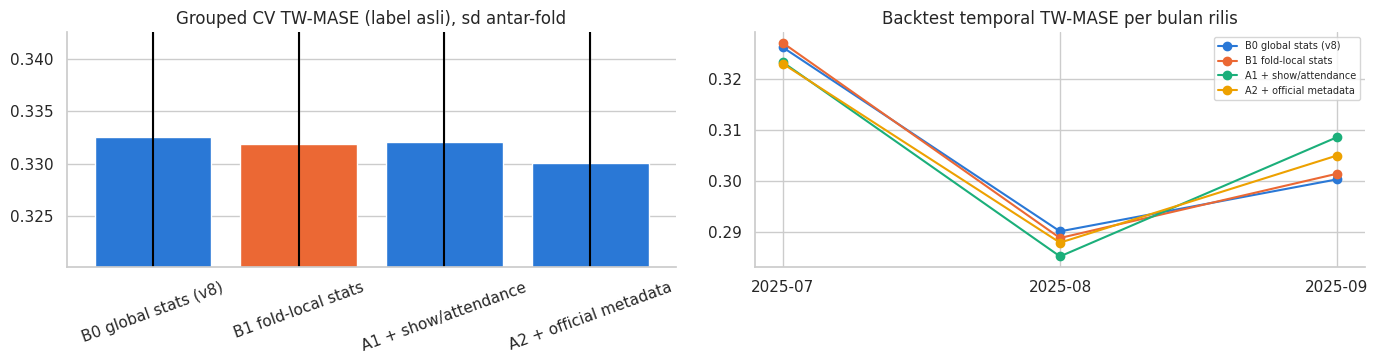

In [26]:
def film_delta_ci(p_new, p_ref):
    d = (np.abs(y - p_new) - np.abs(y - p_ref)) / s * TW
    G = pd.DataFrame({'g': groups, 'd': d, 'w': TW}).groupby('g').sum()
    ix = np.random.default_rng(CFG.SEED).integers(0, len(G), (2000, len(G)))
    b = G.d.values[ix].sum(1) / G.w.values[ix].sum(1)
    return np.quantile(b, [0.025, 0.5, 0.975]), int((G.d < 0).sum()), len(G)


rows = []
for cand in ['A1 + show/attendance', 'A2 + official metadata']:
    ok, checks = passes(L, cand)
    ci, better, nf = film_delta_ci(RUNS[cand]['pred'], RUNS[REF]['pred'])
    rows.append(dict(candidate=cand, adopted=ok, **checks, film_delta_ci95=f'[{ci[0]:+.4f}, {ci[2]:+.4f}]', films_better=f'{better}/{nf}'))
D = pd.DataFrame(rows).set_index('candidate')
display(D)
adopted = list(D.index[D.adopted])
COMPLEXITY = {REF: 0, 'A1 + show/attendance': 1, 'A2 + official metadata': 1, 'C combined': 2}
cands = list(adopted)
if len(adopted) == 2:
    run_config('C combined', dict(cin='local', meta=True, aux=True))
    L.loc['C combined'] = pd.Series(lens(RUNS['C combined']['pred'], temporal_pred(RUNS['C combined'])))
    ok, checks = passes(L, 'C combined')
    print('combined vs B1:', checks)
    if ok:
        cands.append('C combined')
SELECTED = REF
if cands:
    best = L.loc[cands, 'TW'].idxmin()
    # a simpler passing configuration wins unless the more complex one is better by at least ABL_MIN_GAIN
    simpler = [c for c in cands if COMPLEXITY[c] < COMPLEXITY[best] and L.loc[c, 'TW'] - L.loc[best, 'TW'] < CFG.ABL_MIN_GAIN]
    SELECTED = min(simpler, key=lambda c: L.loc[c, 'TW']) if simpler else best
SEL = RUNS[SELECTED]
SEL_FEATS = SEL['frames'][0][2]
print(f'SELECTED configuration: {SELECTED} | features {len(SEL_FEATS)}')

fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
names_ = list(L.index)
ax[0].bar(range(len(names_)), L.TW, color=[PAL[1] if n_ == SELECTED else PAL[0] for n_ in names_])
ax[0].errorbar(range(len(names_)), L.TW, yerr=L[[f'fold{k}' for k in range(CFG.N_FOLDS)]].std(axis=1), fmt='none', color='k', capsize=3)
ax[0].set_xticks(range(len(names_)), names_, rotation=20); ax[0].set(title='Grouped CV TW-MASE (label asli), sd antar-fold', ylim=(L.TW.min() - .01, L.TW.max() + .01))
for n_ in names_:
    ax[1].plot(MONTHS, L.loc[n_, [f'temp_{m}' for m in MONTHS]].values, marker='o', label=n_)
ax[1].set(title='Backtest temporal TW-MASE per bulan rilis'); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'ablation.png'); plt.show()

#### Insights

> Tabel ablation dibaca terhadap B1, bukan B0: B0 memakai statistik klaster yang melihat transaksi film validasi, sehingga selisih B0 ke B1 adalah besar kebocoran yang sebelumnya tidak terukur. Kandidat yang lolos harus menang di grouped CV, backtest temporal, mayoritas fold, dan tidak memburuk di dunia $\kappa$. Interval bootstrap per film memperlihatkan seberapa bergantung hasilnya pada komposisi film; interval yang melewati nol berarti perbaikannya belum kokoh.

> Kalender wilayah (Jawa Barat) tidak masuk tangga ablation karena hampir tidak mengubah train: di periode latih jendela libur hari kerjanya identik dengan DKI, sehingga $c_{mult}$ latih sama persis dan hanya flag `t_school` pada akhir pekan 28 sampai 29 Juni (202 baris) yang berbeda. Koreksi itu terutama mengubah baris uji (Bagian 7, 1,6% baris) dan diterapkan sebagai koreksi fakta bersumber, bukan hasil validasi.

## Sensitivitas $\lambda$ (Dibekukan 0,5)

$\lambda$ tidak dioptimalkan ulang. Tabel berikut hanya memperlihatkan arah sensitivitas pada konfigurasi terpilih: label asli, backtest temporal, dan dunia $\kappa$.

In [27]:
lam_rows = []
for lam in (0.0, 0.25, 0.5, 0.75, 1.0):
    p = lgb_mix(SEL['oof']['l1'], SEL['oof']['p0'], SEL['oof']['Q'], lam=lam) * cm * s
    r = lens(p, temporal_pred(SEL, lam=lam))
    lam_rows.append(dict(lam=lam, TW=r['TW'], temporal_mean=r['temporal_mean'], kappa=r['kappa']))
display(pd.DataFrame(lam_rows).set_index('lam').round(4))
oof_l1, oof_lgbmix = SEL['oof']['l1'], SEL['pred']
results.append(score(oof_lgbmix, f'LightGBM mix [{SELECTED}]'))

,TW,temporal_mean,kappa
lam,,,
0.00,0.3284,0.3041,0.3459
0.25,0.3296,0.3041,0.3437
0.50,0.3319,0.3058,0.3427
0.75,0.3352,0.3077,0.3429
1.00,0.3400,0.3109,0.3443


LightGBM mix [B1 fold-local stats]       MASE 0.3132 | TW-MASE 0.3319 (old 0.3906) | s<=20 0.8210 | s>200 0.2632


## Pretrained Model pada Konfigurasi Terpilih

Foundation model hanya dievaluasi pada konfigurasi LightGBM yang terpilih, memakai fitur yang sama (tanpa `h`, satu model per horizon) dan bagian latih per fold yang sama, termasuk fitur bantu bersarang bila terpilih.

**Status kepatuhan.** `FM_MODE` memilih komponen: `'exaone'` memakai EXAONE-Tabular (LG AI Research, rilis Agustus 2026, 84,5 MB, revisi `093ad1c2`); `'tabpfn_v2'` memakai TabPFN v2 regressor pada revisi `213f8e38` (11 Juni 2025, sebelum batas 30 September 2025, 44,4 MB); `'none'` hanya LightGBM. Aturan lomba tidak menyatakan eksplisit apakah batas tanggal berlaku untuk checkpoint; tim membacanya sebagai aturan data eksternal, tetapi konfirmasi panitia belum ada. Opsi `tabpfn_v2` dan `none` disediakan bila panitia memutuskan sebaliknya. Semua checkpoint di bawah 200 MB dan ditanam di berkas bobot.

EXAONE-Tabular hanya mengembalikan titik (trimmed mean); kepalanya mengeluarkan 999 kuantil per anggota ensemble, sehingga kelas turunan membaca kuantil pada grid yang sama lalu merata-ratakannya antar anggota. Backend attention dialihkan dari FlashAttention (tidak ada di T4) ke kernel memory-efficient pada sel import. Dengan `STRICT = True`, kegagalan komponen menghentikan notebook alih-alih diam-diam menormalisasi ulang blend. Checkpoint yang dipakai (dari input Kaggle, dari berkas bobot, atau unduhan) selalu diverifikasi dengan SHA-256 revisi terkunci; berkas lain dengan nama sama ditolak.

In [28]:
TAB_QS = CFG.TAB_QS


def hf_token():
    if os.environ.get('HF_TOKEN'):
        return os.environ['HF_TOKEN']
    if UserSecretsClient is not None:
        try:
            return UserSecretsClient().get_secret('HF_TOKEN')
        except Exception:
            return None
    return None


def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()


def checkpoint_path(repo, fname, rev, digest):
    path = find_checkpoint(repo, fname, rev)
    got = sha256(path)
    if got != digest:
        raise RuntimeError(f'{fname}: SHA-256 {got} does not match the pinned revision ({digest})')
    print(f'{fname}: SHA-256 verified ({path})')
    return path


def find_checkpoint(repo, fname, rev):
    roots = [Path('/kaggle/input')] if CFG._ON_KAGGLE else []
    for root in roots:
        hit = list(root.rglob(fname))
        if hit:
            return str(hit[0])
        for pk in root.rglob('*.pkl'):
            try:
                with open(pk, 'rb') as f:
                    blob = pickle.load(f).get('fm_files', {})
            except Exception:
                continue
            if fname in blob:
                out = CFG.OUTPUT_DIR / 'fm' / fname
                out.parent.mkdir(parents=True, exist_ok=True)
                out.write_bytes(blob[fname])
                return str(out)
    # local_dir keeps the real file name: loaders pick the format from the suffix
    return hf_hub_download(repo, fname, revision=rev, token=hf_token(), local_dir=str(CFG.OUTPUT_DIR / 'fm'))


class EXAONEQuantile(EXAONETabularRegressor if EXAONETabularRegressor is not None else object):
    _taus = None

    def _collapse_members(self, output, query_count):
        if self._taus is None:
            return super()._collapse_members(output, query_count)
        q = torch.sort(output.float(), dim=-1).values
        n = q.shape[-1]
        idx = torch.as_tensor(np.clip(np.round(np.asarray(self._taus) * (n + 1)).astype(int) - 1, 0, n - 1), device=q.device)
        return q[..., idx]

    def predict_quantiles(self, X, taus):
        st = self._state()
        query = st['preprocessor'].transform(X).values
        self._taus = list(taus)
        try:
            mp = self._pooled_member_points(torch.as_tensor(st['support_x'], dtype=torch.float32, device=self.device),
                                            torch.as_tensor(st['support_y'], dtype=torch.float32, device=self.device),
                                            torch.as_tensor(query, dtype=torch.float32, device=self.device), st['passes'])
        finally:
            self._taus = None
        return np.sort((mp * st['scale'] + st['center']).mean(dim=0).cpu().numpy().astype(np.float64), axis=1)


FM_SPEC = {'exaone': (CFG.EXAONE_REPO, CFG.EXAONE_FILE, CFG.EXAONE_REV, CFG.EXAONE_SHA256),
           'tabpfn_v2': (CFG.TABPFN_REPO, CFG.TABPFN_FILE, CFG.TABPFN_REV, CFG.TABPFN_SHA256)}


def fm_model(ckpt):
    if CFG.FM_MODE == 'exaone':
        return EXAONEQuantile.from_pretrained(weights=ckpt, device=CFG.DEVICE, ensemble_count=CFG.FM_EST,
                                              compute_dtype='float16' if CFG.DEVICE == 'cuda' else 'float32', seed=CFG.SEED)
    return TabPFNRegressor.create_default_for_version(ModelVersion.V2, model_path=ckpt, device=CFG.DEVICE, n_estimators=CFG.FM_EST,
                                                      random_state=CFG.SEED, ignore_pretraining_limits=True)


def fm_quantiles(Xa, Xb, feats):
    tf = [c for c in feats if c != 'h']
    out = np.zeros((len(Xb), len(TAB_QS)))
    for hz in range(4, 11):
        ia, ib = (Xa.h == hz).values, (Xb.h == hz).values
        if ib.sum() == 0:
            continue
        m = fm_model(FM_CKPT)
        m.fit(Xa[ia][tf].values.astype(np.float32), r_target(Xa)[ia])
        Qb = Xb[ib][tf].values.astype(np.float32)
        if CFG.FM_MODE == 'exaone':
            out[ib] = np.concatenate([m.predict_quantiles(Qb[i:i + 3000], TAB_QS) for i in range(0, len(Qb), 3000)])
        else:
            out[ib] = np.concatenate([np.asarray(m.predict(Qb[i:i + 3000], output_type='quantiles', quantiles=list(TAB_QS))).T
                                      for i in range(0, len(Qb), 3000)])
        del m
        torch.cuda.empty_cache()
    return np.sort(out, axis=1)


def fm_median(Q, lam=None):
    lam = CFG.LAMBDA if lam is None else lam
    p0 = np.array([np.interp(CFG.ZERO_EPS, q, TAB_QS, left=0.0, right=1.0) for q in Q])
    p = sigm(logit(np.clip(p0, 1e-4, 1 - 1e-4)) + lam * PULL_A)
    u = np.clip(p0 + (1 - p0) * (0.5 - p) / (1 - p), TAB_QS[0], TAB_QS[-1])
    val = np.array([np.interp(ui, TAB_QS, qi) for ui, qi in zip(u, Q)])
    return np.where(p >= 0.5, 0.0, np.clip(val, 0, None))


oof_fmQ, fm_temporal, FM_CKPT = None, {}, None
if CFG.FM_MODE != 'none':
    if CFG.FM_MODE == 'exaone' and EXAONETabularRegressor is None:
        raise RuntimeError('FM_MODE=exaone but exaonetabular could not be imported')
    t0 = time.time()
    try:
        FM_CKPT = checkpoint_path(*FM_SPEC[CFG.FM_MODE])
        oof_fmQ = np.zeros((len(Xtr), len(TAB_QS)))
        for k in range(CFG.N_FOLDS):
            Xa_, Xb_, f_ = SEL['frames'][k]
            oof_fmQ[FOLD == k] = fm_quantiles(Xa_, Xb_, f_)
            print(f'{CFG.FM_MODE} fold {k} done ({time.time() - t0:.0f}s)')
        for mth, t in SEL['temporal'].items():
            fm_temporal[mth] = fm_quantiles(*t['frames'])
        print(f'{CFG.FM_MODE} temporal done ({time.time() - t0:.0f}s)')
    except Exception as e:
        if CFG.STRICT:
            raise
        print(f'{CFG.FM_MODE} skipped:', type(e).__name__, str(e)[:300])
        oof_fmQ = None
    if oof_fmQ is not None:
        results.append(score(fm_median(oof_fmQ) * cm * s, f'{CFG.FM_MODE} median (lambda)'))

exaone-tabular-regressor-v1_default.safe(…):   0%|          | 0.00/84.5M [00:00<?, ?B/s]

exaone-tabular-regressor-v1_default.safetensors: SHA-256 verified (/kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors)


using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 6427 rows yields 1285 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 6427 rows yields 1285 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 6427 rows yields 1285 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working

exaone fold 0 done (604s)


support of 6715 rows yields 1343 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 6813 rows yields 1362 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 6715 rows yields 1343 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 6715 rows yields 1343 validation ro

...

exaone fold 3 done (2493s)


support of 6790 rows yields 1358 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 6888 rows yields 1377 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 6790 rows yields 1358 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 6790 rows yields 1358 validation ro

exaone fold 4 done (3133s)


support of 3108 rows yields 621 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 3206 rows yields 641 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 3108 rows yields 621 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 3108 rows yields 621 validation rows, 

exaone temporal done (4391s)
exaone median (lambda)                   MASE 0.3097 | TW-MASE 0.3260 (old 0.3856) | s<=20 0.8068 | s>200 0.2604


## Blending dan Keputusan Foundation Model

Bobot foundation model dicari pada grid 0,1 dengan **label asli** (TW-MASE grouped CV) sebagai lensa utama. Blend hanya dipakai bila (1) memperbaiki TW-MASE minimal `FM_MIN_GAIN` (0,001) terhadap LightGBM saja, (2) rata-rata backtest temporal pada bobot yang sama tidak memburuk, dan (3) dunia $\kappa$ tidak memburuk lebih dari `ABL_KAPPA_TOL`. Semua bobot yang memenuhi ketiga syarat disaring dulu, lalu dipilih TW-MASE terbaik di antaranya; bila tidak ada yang lolos, konfigurasi yang lebih sederhana (LightGBM saja) dipertahankan.

In [29]:
WEIGHTS = {'lgb': 1.0}
p_lgb = oof_lgbmix
tp_lgb = temporal_pred(SEL)
base_l = lens(p_lgb, tp_lgb)
if oof_fmQ is not None:
    p_fm = fm_median(oof_fmQ) * cm * s
    tp_fm = {m: (t['idx'], fm_median(fm_temporal[m]) * cm[t['idx']] * s[t['idx']]) for m, t in SEL['temporal'].items()}
    rows = []
    for w_fm in np.round(np.arange(0, 1.01, 0.1), 1):
        p = (1 - w_fm) * p_lgb + w_fm * p_fm
        tp = {m: (i, (1 - w_fm) * tp_lgb[m][1] + w_fm * tp_fm[m][1]) for m, (i, _) in tp_lgb.items()}
        rows.append(dict(w_fm=w_fm, **lens(p, tp)))
    BW = pd.DataFrame(rows).set_index('w_fm')
    display(BW[['TW', 'TW_OLD', 'temporal_mean', 'kappa'] + [f'temp_{m}' for m in MONTHS]].round(4))
    BW['pass'] = ((BW.index > 0) & (base_l['TW'] - BW.TW >= CFG.FM_MIN_GAIN) & (BW.temporal_mean <= base_l['temporal_mean'])
                  & (BW.kappa - base_l['kappa'] <= CFG.ABL_KAPPA_TOL))
    print('FM weights passing every condition:', list(BW.index[BW['pass']]))
    if BW['pass'].any():
        w_star = float(BW[BW['pass']].TW.idxmin())
        WEIGHTS = {'lgb': round(1 - w_star, 1), 'fm': w_star}
    err = pd.DataFrame({'lgb': (y - p_lgb) / s, 'fm': (y - p_fm) / s})
    print('signed-error correlation lgb vs fm:', round(float(err.corr().iloc[0, 1]), 3))
oof_final = WEIGHTS['lgb'] * p_lgb + (WEIGHTS.get('fm', 0) * fm_median(oof_fmQ) * cm * s if 'fm' in WEIGHTS else 0)
print('chosen weights:', WEIGHTS)
results.append(score(oof_final, 'final blend'))
results.append(score(oof_final, 'final blend, kappa world 0', yy=WORLDS[0]))
display(pd.DataFrame(results).set_index('model').round(4))

,TW,TW_OLD,temporal_mean,kappa,temp_2025-07,temp_2025-08,temp_2025-09
w_fm,,,,,,,
0.0,0.3319,0.3906,0.3058,0.3427,0.3270,0.2889,0.3015
0.1,0.3300,0.3887,0.3037,0.3416,0.3247,0.2882,0.2983
0.2,0.3284,0.3870,0.3020,0.3409,0.3227,0.2879,0.2954
0.3,0.3270,0.3857,0.3006,0.3406,0.3209,0.2879,0.2929
0.4,0.3260,0.3847,0.2995,0.3405,0.3195,0.2883,0.2907
0.5,0.3252,0.3841,0.2987,0.3408,0.3183,0.2889,0.2888
0.6,0.3248,0.3838,0.2982,0.3415,0.3176,0.2898,0.2871
0.7,0.3247,0.3838,0.2980,0.3425,0.3171,0.2911,0.2859
0.8,0.3248,0.3841,0.2982,0.3438,0.3170,0.2926,0.2852


FM weights passing every condition: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
signed-error correlation lgb vs fm: 0.987
chosen weights: {'lgb': 0.3, 'fm': 0.7}
final blend                              MASE 0.3072 | TW-MASE 0.3247 (old 0.3838) | s<=20 0.8092 | s>200 0.2575
final blend, kappa world 0               MASE 0.3150 | TW-MASE 0.3408 (old 0.4037) | s<=20 0.8854 | s>200 0.2546


,MASE,TW_MASE,TW_OLD,small,big
model,,,,,
zero,0.5881,0.5394,0.6104,0.8820,0.6309
"median r/c by (h, D1 dow)",0.4002,0.4330,0.4951,0.9822,0.3279
LightGBM mix [B1 fold-local stats],0.3132,0.3319,0.3906,0.8210,0.2632
exaone median (lambda),0.3097,0.3260,0.3856,0.8068,0.2604
final blend,0.3072,0.3247,0.3838,0.8092,0.2575
"final blend, kappa world 0",0.3150,0.3408,0.4037,0.8854,0.2546


#### Insights

> Foundation model dinilai setelah konfigurasi LightGBM dikunci, sehingga pemilihan fitur, model, dan bobot blend tidak terjadi sekaligus. Pada v9, EXAONE-Tabular (0,3258) hampir menyamai TabPFN-3.5 (0,3246) dan TabPFN-2.6 (0,3298) di TW-MASE dengan $\lambda = 0{,}5$, tetapi bobot blend v9 dipilih di dunia $\kappa$ yang dibangun dari kuantil LightGBM, sehingga cenderung memihak LightGBM. v10 memilih bobot dengan label asli dan memakai backtest temporal serta dunia $\kappa$ hanya sebagai syarat tidak memburuk.

---

# Evaluation <a name="9"></a>

---

Galat out-of-fold model final dibedah per bucket skala, per horizon, per bulan rilis, dan per film. Kontribusi per bucket dihitung dengan porsi uji, dan sensitivitas skor terhadap komposisi film diukur dengan bootstrap per film.

,test_share,train_share,mase,zero_rate,contribution_to_test
scale,,,,,
"(0.0, 5.0]",0.015,0.003,2.561,0.758,0.040
"(5.0, 20.0]",0.114,0.029,0.637,0.761,0.073
"(20.0, 50.0]",0.198,0.101,0.404,0.622,0.080
"(50.0, 100.0]",0.200,0.169,0.315,0.520,0.063
"(100.0, 200.0]",0.195,0.235,0.290,0.333,0.057
"(200.0, 500.0]",0.178,0.276,0.276,0.151,0.049
"(500.0, 1000000000.0]",0.100,0.188,0.230,0.026,0.023


TW-MASE by horizon: {4: 0.409, 5: 0.448, 6: 0.319, 7: 0.316, 8: 0.263, 9: 0.259, 10: 0.258}
TW-MASE by release month: {'2025-04': 0.356, '2025-05': 0.461, '2025-06': 0.284, '2025-07': 0.302, '2025-08': 0.272, '2025-09': 0.282}
top-5 films carry 29.0% of the weighted error: ['LILO & STITCH', 'SAYAP SAYAP PATAH 2: OLIVIA', 'SORE ISTRI DARI MASA DEPAN', 'UNTIL DAWN', 'WEAPONS']
final vs B0 (v8-like) film bootstrap 95% CI of TW change: [-0.0148, -0.0010] | films better 81/126


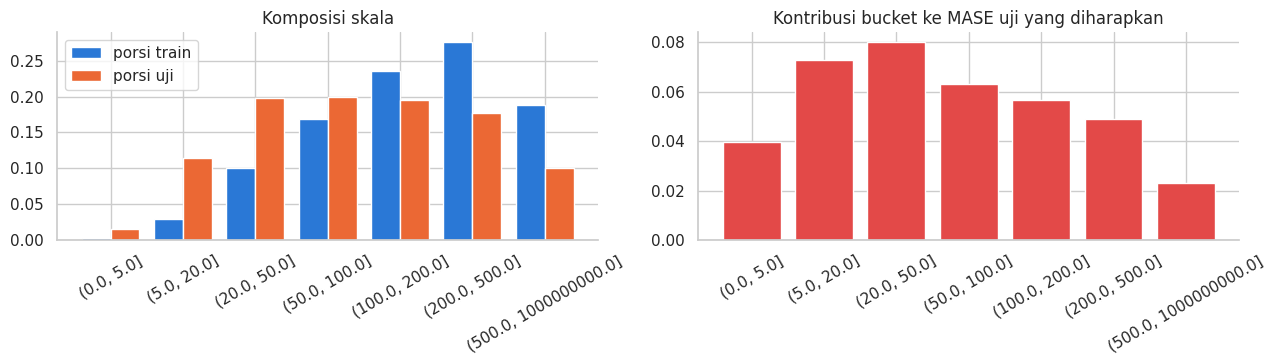

In [30]:
E = Xtr[['movie_title', 'h', 'scale', 'total_ticket', 'd1']].assign(pred=oof_final, w=TW)
E['ae'] = np.abs(E.total_ticket - E.pred) / E.scale
cut = pd.cut(E.scale, CFG.TW_BINS)
bk = pd.DataFrame({'test_share': pd.cut(Xte.scale, CFG.TW_BINS).value_counts(normalize=True), 'train_share': cut.value_counts(normalize=True),
                   'mase': E.groupby(cut, observed=False).ae.mean(), 'zero_rate': (E.total_ticket == 0).groupby(cut, observed=False).mean()}).sort_index()
bk['contribution_to_test'] = bk.test_share * bk.mase
display(bk.round(3))
wm = lambda g: np.average(g.ae, weights=g.w)
print('TW-MASE by horizon:', E.groupby('h').apply(wm, include_groups=False).round(3).to_dict())
print('TW-MASE by release month:', E.groupby(E.d1.dt.strftime('%Y-%m')).apply(wm, include_groups=False).round(3).to_dict())
fe = E.assign(c=E.ae * E.w / E.w.sum()).groupby(base_title(E.movie_title)).c.sum()
print(f'top-5 films carry {fe.nlargest(5).sum() / fe.sum():.1%} of the weighted error:', fe.nlargest(5).index.tolist())
ci, better, nf = film_delta_ci(oof_final, RUNS['B0 global stats (v8)']['pred'])
print(f'final vs B0 (v8-like) film bootstrap 95% CI of TW change: [{ci[0]:+.4f}, {ci[2]:+.4f}] | films better {better}/{nf}')

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
xx = np.arange(len(bk))
ax[0].bar(xx - .2, bk.train_share, .4, label='porsi train'); ax[0].bar(xx + .2, bk.test_share, .4, label='porsi uji')
ax[0].set_xticks(xx, [str(i) for i in bk.index], rotation=30); ax[0].legend(); ax[0].set_title('Komposisi skala')
ax[1].bar(xx, bk.contribution_to_test, color=PAL[7]); ax[1].set_xticks(xx, [str(i) for i in bk.index], rotation=30)
ax[1].set_title('Kontribusi bucket ke MASE uji yang diharapkan')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'evaluation.png'); plt.show()

#### Insights

> Pasangan dengan skala di bawah 50 hanya sekitar 13% baris train tetapi 33% baris uji dan menyumbang porsi terbesar MASE uji yang diharapkan. Lima film menyumbang kira-kira seperempat sampai sepertiga galat berbobot (`eda/51`), sehingga perbedaan versi di bawah lebar interval bootstrap per film tidak boleh dibaca sebagai perbaikan pasti.

---

# Inference & Submission <a name="10"></a>

---

Model final dilatih pada seluruh sampel (rilis luas dan rilis terbatas) dengan konfigurasi terpilih. Statistik klaster untuk data uji memakai seluruh train (masa lalu film uji). Bila fitur bantu terpilih, fitur baris latih berasal dari inner fold dan fitur uji dari model bantu yang dilatih pada seluruh train. Tidak ada parameter yang disetel pada leaderboard.

## Minggu Lebaran: Analog Top-Down dari Lebaran 2025

Tujuh judul slate Lebaran 2026 dirilis 18 Maret, sehingga D4 sampai D10 mereka adalah Lebaran hari 1 sampai 7 (6,1% baris uji), periode yang tidak memiliki padanan di sampel latih. Namun `train.csv` dimulai 1 April 2025, yaitu Lebaran 2025 hari ke-2, sehingga total tiket per klaster selama minggu Lebaran 2025 teramati. Prediksi top-down: total slate per klaster pada Lebaran hari ke-$k$ = $\rho$ x total klaster pada Lebaran 2025 hari ke-$k$, dibagi ke pasangan menurut pangsa skala D1 sampai D3. Rasio klaster dirata-rata geometrik dengan rasio nasional agar tidak liar pada klaster kecil.

slate: ['DANUR: THE LAST CHAPTER', 'DANUR: THE LAST CHAPTER (IMAX 2D)', 'NA WILLA', 'PELANGI DI MARS', 'SENIN HARGA NAIK', 'SUZZANNA: SANTET DOSA DI ATAS DOSA', 'TUNGGU AKU SUKSES NANTI']
normal 2025 day 217072 | 2025 Lebaran week mean 593714 | 2026 slate mean D1-D3 167461
2026 slate: 1003361 seats/day at occupancy 17% | 2025 slate occupancy median 73%


,rho=0.4,rho=0.5,rho=0.7,rho=1.0,occupancy_needed_rho=0.5
D4 (Lebaran day 1),0.83,1.03,1.45,2.07,17.0
D5 (Lebaran day 2),1.10,1.38,1.93,2.76,23.0
D6 (Lebaran day 3),1.34,1.68,2.35,3.35,28.0
D7 (Lebaran day 4),1.51,1.89,2.64,3.77,31.0
D8 (Lebaran day 5),1.49,1.86,2.61,3.72,31.0
D9 (Lebaran day 6),1.58,1.98,2.77,3.96,33.0
D10 (Lebaran day 7),1.48,1.85,2.59,3.71,31.0


analog mean r by Lebaran day: {1: 1.09, 2: 1.45, 3: 1.78, 4: 2.01, 5: 1.98, 6: 2.1, 7: 1.98}


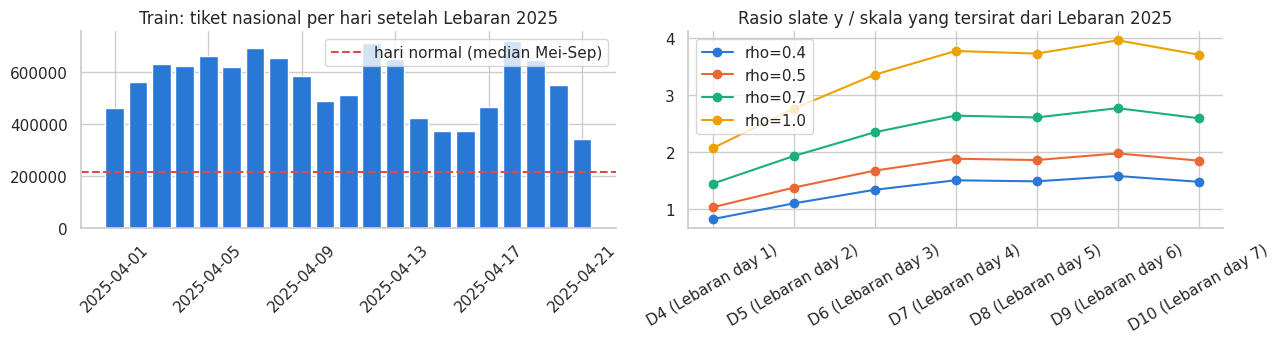

In [31]:
LEB25, LEB26 = pd.Timestamp('2025-03-31'), pd.Timestamp('2026-03-21')
leb_mask = Xte.date_show.between(LEB26, LEB26 + pd.Timedelta(days=6)).values
slate = sorted(Xte.movie_title[leb_mask].unique())
hsl = hist[hist.movie_title.isin(slate)]
day25 = train.groupby('date_show').total_ticket.sum()
normal_day = day25.loc['2025-05-01':].median()
m25 = pd.Series({k: day25[LEB25 + pd.Timedelta(days=k - 1)] for k in range(2, 8)})
m25.loc[1] = CFG.LEB_DAY1 * m25.loc[2]
m25 = m25.sort_index()
S26 = hsl.groupby('date_show').total_ticket.sum().mean()
seats26 = (hsl.total_ticket / (hsl.occupation_rate / 100).clip(lower=.005)).groupby(hsl.date_show).sum().mean()
top25 = train[train.date_show.between('2025-04-01', '2025-04-07')].groupby('movie_title').total_ticket.sum().nlargest(5).index
a25 = train[train.movie_title.isin(top25) & train.date_show.between('2025-04-01', '2025-04-07')]
print('slate:', slate)
print(f'normal 2025 day {normal_day:.0f} | 2025 Lebaran week mean {m25.loc[2:7].mean():.0f} | 2026 slate mean D1-D3 {S26:.0f}')
print(f'2026 slate: {seats26:.0f} seats/day at occupancy {100 * S26 / seats26:.0f}% | 2025 slate occupancy median {a25.occupation_rate.median():.0f}%')
imp_r = pd.DataFrame({f'rho={r_}': r_ * m25 / S26 for r_ in (0.4, 0.5, 0.7, 1.0)})
imp_r.index = [f'D{k + 3} (Lebaran day {k})' for k in imp_r.index]
imp_r['occupancy_needed_rho=0.5'] = (0.5 * m25.values / seats26 * 100).round(0)
display(imp_r.round(2))

c25 = {k: train[train.date_show == LEB25 + pd.Timedelta(days=k - 1)].groupby('cinema_ids').total_ticket.sum() for k in range(2, 8)}
c25[1] = CFG.LEB_DAY1 * c25[2]
c26 = hsl.groupby('cinema_ids').total_ticket.sum() / 3
kday = (Xte.date_show - LEB26).dt.days.values + 1
leb_pred = np.zeros(len(Xte))
for k in range(1, 8):
    m = leb_mask & (kday == k)
    r_nat = m25.loc[k] / S26
    r_cl = (Xte.cinema_ids[m].map(c25[k]) / Xte.cinema_ids[m].map(c26)).values
    r_cl = np.where(np.isfinite(r_cl) & (r_cl > 0), r_cl, r_nat)
    # geometric mean of cluster and national ratio
    leb_pred[m] = Xte.scale.values[m] * CFG.LEB_RHO * np.sqrt(r_cl * r_nat)
print('analog mean r by Lebaran day:', {int(k): round(float((leb_pred / Xte.scale.values)[leb_mask & (kday == k)].mean()), 2) for k in range(1, 8)})

dd = day25.loc['2025-04-01':'2025-04-21']
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].bar(dd.index, dd.values, color=PAL[0]); ax[0].axhline(normal_day, color=PAL[7], ls='--', label='hari normal (median Mei-Sep)')
ax[0].set(title='Train: tiket nasional per hari setelah Lebaran 2025'); ax[0].legend(); ax[0].tick_params(axis='x', rotation=45)
imp_r[['rho=0.4', 'rho=0.5', 'rho=0.7', 'rho=1.0']].plot(ax=ax[1], marker='o'); ax[1].tick_params(axis='x', rotation=30)
ax[1].set(title='Rasio slate y / skala yang tersirat dari Lebaran 2025')
plt.tight_layout(); plt.savefig(CFG.FIG_DIR / 'lebaran.png'); plt.show()

#### Insights

> Minggu Lebaran 2025 berjalan di sekitar 608 ribu tiket per hari pada klaster yang sama (2,8 kali hari normal) dan tetap 2,3 sampai 3 kali normal pada hari kerja setelah cuti bersama. Slate 2026 sudah menawarkan sekitar satu juta kursi per hari pada D1 sampai D3 dengan okupansi hanya 15 sampai 23%, sedangkan slate Lebaran 2025 mencapai okupansi median 73%. Model statistik memprediksi slate turun ke sekitar 129 ribu tiket per hari (rasio 0,79, anjlok ke 0,25 pada 25 sampai 27 Maret), setara okupansi 13% pada minggu puncak tahunan, yang tidak masuk akal secara fisik.

> Analog memakai $\rho = 0{,}5$: slate diasumsikan hanya mencapai separuh total pasar Lebaran 2025 (rasio rata-rata sekitar 1,7, okupansi tersirat di bawah 35%). Bahkan skenario pesimis (pasar 60% dari 2025 dan pangsa slate 70%) memberi rasio 1,4. Nilai ini ditetapkan dari data 2025 dan kapasitas kursi, bukan dari leaderboard. Sumber eksternal pendukung yang terbit sebelum batas: pemberitaan April 2025 tentang 2 juta penonton dalam 3 hari libur Lebaran dan 5 juta penonton selama libur Lebaran.

In [32]:
t0 = time.time()
Xall = pd.concat([Xtr, Xlim], ignore_index=True) if CFG.USE_LIMITED else Xtr
cfg_sel = SEL['cfg']
XA, XT, feats_f, zfeats_f, aux_final = make_parts(Xall, Xte, cfg_sel, STATS_ALL)
final_lgb = fit_lgb_all(XA, feats_f, zfeats_f)
te_l1, te_p0, te_Q = predict_lgb_all(final_lgb, XT, feats_f, zfeats_f)
cm_te, s_te_ = Xte.cal_mult.values, Xte.scale.values
te_comp = {'lgb': lgb_mix(te_l1, te_p0, te_Q) * cm_te * s_te_}
if WEIGHTS.get('fm', 0) > 0:
    te_comp['fm'] = fm_median(fm_quantiles(XA, XT, feats_f)) * cm_te * s_te_
assert set(te_comp) == set(WEIGHTS), f'component mismatch {set(te_comp)} vs {set(WEIGHTS)}'
pred = np.clip(sum(WEIGHTS[n] * te_comp[n] for n in te_comp), 0, None)
print('model mean r on Lebaran rows:', round(float((pred / s_te_)[leb_mask].mean()), 3), '-> analog', round(float((leb_pred / s_te_)[leb_mask].mean()), 3))
pred = np.where(leb_mask, leb_pred, pred)
print(f'final fit + inference: {time.time() - t0:.0f}s')

seg = pd.Series('normal', index=Xte.index)
for n, (a, b) in SEGMENTS.items():
    seg[Xte.date_show.between(a, b)] = n
rr = pred / s_te_
display(pd.DataFrame({'rows': seg.value_counts(), 'mean_r_hat': pd.Series(rr).groupby(seg.values).mean(),
                      'pred_zero_share': pd.Series(rr < .05).groupby(seg.values).mean()}).round(3))

using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 8220 rows yields 1644 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 8318 rows yields 1663 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working/fm/exaone-tabular-regressor-v1_default.safetensors; released-checkpoint integrity pin not enforced (SHA-256 not checked)
support of 8220 rows yields 1644 validation rows, fewer than nnls_min_validation_rows=2000; aggregating ensemble members with uniform weights instead
using user-supplied weights at /kaggle/working

model mean r on Lebaran rows: 0.698 -> analog 1.769
final fit + inference: 3849s


,rows,mean_r_hat,pred_zero_share
lebaran,4417,1.769,0.000
normal,50551,0.452,0.275
ramadan,12408,0.355,0.415
xmas,5235,0.594,0.063


Submisi disimpan dengan format `id,total_ticket` dan urutan `id` yang sama dengan `sample_submission.csv`. Seluruh bobot (booster LightGBM terkompresi, model bantu bila dipakai, dan checkpoint foundation model yang dipakai) disimpan dalam satu berkas `.pkl`, dengan pemeriksaan batas 200 MB yang menghentikan notebook bila terlampaui.

In [33]:
submission = pd.DataFrame({'id': test.id.values, 'total_ticket': pred})
assert len(submission) == len(sub) and (submission.id.values == sub.id.values).all()
assert submission.total_ticket.notna().all() and (submission.total_ticket >= 0).all()
submission.to_csv(CFG.OUTPUT_DIR / 'submission.csv', index=False)
pd.DataFrame({'movie_title': Xtr.movie_title, 'cinema_ids': Xtr.cinema_ids, 'h': Xtr.h, 'fold': FOLD, 'y': y, 'scale': s,
              'oof_b0': RUNS['B0 global stats (v8)']['pred'], 'oof_b1': RUNS[REF]['pred'], 'oof_lgbmix': oof_lgbmix,
              'oof_final': oof_final}).to_csv(CFG.OUTPUT_DIR / 'oof.csv', index=False)
zs = lambda m: zlib.compress(m.booster_.model_to_string().encode(), 6)
fm_files = {FM_SPEC[CFG.FM_MODE][1]: Path(FM_CKPT).read_bytes()} if 'fm' in te_comp else {}
payload = {'l1': [zs(m) for m in final_lgb['l1']], 'zero_clf': zs(final_lgb['zc']), 'quantiles': [zs(m) for m in final_lgb['qm']],
           'aux': [zs(m) for m in aux_final] if aux_final is not None else [], 'compression': 'zlib(model_to_string)',
           'features': feats_f, 'zero_features': zfeats_f, 'selected_config': SELECTED, 'pull_a': PULL_A, 'blend_weights': WEIGHTS,
           'fm_mode': CFG.FM_MODE, 'fm_files': fm_files, 'fm_revision': FM_SPEC.get(CFG.FM_MODE, (None,) * 4)[2], 'fm_sha256': FM_SPEC.get(CFG.FM_MODE, (None,) * 4)[3],
           'settings': {k: v for k, v in vars(Settings).items() if k.isupper()}}
blob = pickle.dumps(payload)
(CFG.OUTPUT_DIR / 'model_weights.pkl').write_bytes(blob)
print(f'weights: {len(blob) / 1e6:.1f} MB (cap {CFG.MAX_WEIGHTS_MB} MB) | checkpoints inside: {list(fm_files)}')
assert len(blob) / 1e6 <= CFG.MAX_WEIGHTS_MB, 'model weights exceed the 200 MB rule'
display(submission.head())

weights: 109.6 MB (cap 200 MB) | checkpoints inside: ['exaone-tabular-regressor-v1_default.safetensors']


,id,total_ticket
0,1,29.294472
1,2,26.638085
2,3,6.039209
3,4,0.032714
4,5,0.066112


#### Insights

> v10 tidak mengklaim perbaikan sebelum diukur. Keputusan diambil dengan aturan yang ditulis sebelum hasil: statistik klaster fold-local sebagai baseline bersih, satu perubahan per kandidat (perubahan show dan tiket per show; metadata resmi), backtest temporal sebagai syarat, dan foundation model hanya pada konfigurasi terpilih. Kalender wilayah Jawa Barat diterapkan sebagai koreksi fakta bersumber pada baris uji. Level minggu Lebaran tetap dari analog Lebaran 2025, yang tidak tervalidasi oleh OOF.

> Untuk reproduksi, semua komponen yang dipakai disimpan di satu berkas bobot di bawah 200 MB, checkpoint dicari dulu di input Kaggle atau di dalam berkas bobot sebelum ke Hugging Face, dan kegagalan komponen menghentikan notebook (`STRICT = True`) alih-alih mengubah prediksi diam-diam.